# Assignment 3 - Phase 2 & 3
## Model 1: ResNet-50 Encoder + GRU Decoder

**Architecture:** Frozen pretrained ResNet-50 → linear projection → single-layer GRU decoder with teacher forcing  
**Dataset:** VizWiz-Captions validation set (7,750 images, 38,750 captions, 5 captions/image)  
**Required metrics:** BLEU-1, BLEU-2, BLEU-3, BLEU-4

---

### Design rationale

| Component | Choice | Reason |
|---|---|---|
| Encoder | ResNet-50 (frozen) | Strong ImageNet features without expensive backprop through 25M params |
| Projection | Linear(2048 → 512) + ReLU | Adapts visual features to decoder hidden size |
| Decoder | Single-layer GRU | Simpler and faster than LSTM (one fewer gate), sufficient for short captions |
| Training | Teacher forcing (ratio = 1.0) | Stable gradients; model always sees correct previous word |
| Inference | Greedy decoding | Deterministic baseline; straightforward for BLEU comparison |

**Key limitation to address in Model 2 (Phase 3):**  
The image context is compressed into a single vector and injected only once at h₀.
Over longer sequences the GRU hidden state drifts away from image information.
Model 2 will add dropout (per the brief) and an attention mechanism so the decoder
can revisit spatial image regions at every timestep.

## 1. Setup and Imports

In [1]:
# ── Package availability check ───────────────────────────────────────────────
# This notebook only uses NLTK's BLEU implementation.
# It does NOT use nltk.word_tokenize(), so punkt / punkt_tab downloads are not required.

import sys
import subprocess
import importlib.util

def ensure_package(package_name, import_name=None):
    """
    Import a package if available; install it only if missing.
    This avoids repeated pip installs and prevents unnecessary notebook noise.
    """
    import_name = import_name or package_name

    if importlib.util.find_spec(import_name) is None:
        print(f"{package_name} not found. Installing...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", package_name, "-q"
        ])
    else:
        print(f"{package_name} already available.")

ensure_package("nltk")

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

print("NLTK BLEU utilities ready. No tokenizer download required.")

nltk already available.
NLTK BLEU utilities ready. No tokenizer download required.


In [2]:
import os
import re
import json
import random
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import torchvision
import torchvision.transforms as transforms

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

print(f"PyTorch version  : {torch.__version__}")
print(f"Torchvision      : {torchvision.__version__}")
print("All imports successful.")

PyTorch version  : 2.12.0
Torchvision      : 0.27.0
All imports successful.


In [3]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device (Apple Silicon MPS → CUDA → CPU) ──────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Device : {DEVICE}")

# ── Project Paths ─────────────────────────────────────────────────────────────
PROJECT_ROOT       = Path.cwd()
if PROJECT_ROOT.name == "notebooks":          # run from notebooks/ subfolder
    PROJECT_ROOT   = PROJECT_ROOT.parent

DATA_DIR           = PROJECT_ROOT / "data"
RAW_DATA_DIR       = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
IMAGE_DIR          = RAW_DATA_DIR / "val"
ARTEFACTS_DIR      = PROCESSED_DATA_DIR / "artefacts"
CHECKPOINT_DIR     = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Image dir     : {IMAGE_DIR}")
print(f"Artefacts dir : {ARTEFACTS_DIR}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")

# ── Dataset constants (must match Phase 1) ────────────────────────────────────
BATCH_SIZE    = 32
NUM_WORKERS   = 0          # 0 is required on Mac / Jupyter
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# pin_memory is unsupported on MPS; only enable for CUDA
PIN_MEMORY = DEVICE.type == "cuda"

# ── Model hyperparameters ─────────────────────────────────────────────────────
EMBED_DIM      = 256   # word embedding dimension
HIDDEN_DIM     = 512   # GRU hidden size (= encoder projection target)
NUM_GRU_LAYERS = 1     # single-layer GRU for the baseline

# ── Training hyperparameters ──────────────────────────────────────────────────
LEARNING_RATE  = 3e-4
NUM_EPOCHS     = 10
CLIP_GRAD_NORM = 5.0   # gradient clipping threshold
MAX_GEN_LEN    = 50    # max tokens to generate at inference

Device : mps
Image dir     : /Users/shreyash/Documents/Sem3DL/AT3DL/vizwiz-val-image-cap-DL-AT3/data/raw/val
Artefacts dir : /Users/shreyash/Documents/Sem3DL/AT3DL/vizwiz-val-image-cap-DL-AT3/data/processed/artefacts
Checkpoint dir: /Users/shreyash/Documents/Sem3DL/AT3DL/vizwiz-val-image-cap-DL-AT3/checkpoints


## 2. Load Phase 1 Artefacts

The Phase 1 notebook saved five files to `data/processed/artefacts/`:

| File | Contents |
|---|---|
| `vocab.pkl` | `stoi`, `itos`, vocab size, special token indices |
| `splits.json` | Train / val / test image ID lists |
| `id_to_tokens.json` | Image ID → five cleaned token lists |
| `captions_processed.csv` | Full preprocessed caption dataframe |
| `metadata.json` | Reproducibility summary |

No Phase 1 code is re-run here — all objects are rebuilt from saved files.

In [4]:
# ── Vocabulary ───────────────────────────────────────────────────────────────
with open(ARTEFACTS_DIR / "vocab.pkl", "rb") as f:
    vocab_data = pickle.load(f)

# itos can be either:
#   dict: {0: "<PAD>", 1: "<START>", ...}
#   list: ["<PAD>", "<START>", ...]
raw_itos = vocab_data["itos"]
raw_stoi = vocab_data["stoi"]

if isinstance(raw_itos, dict):
    itos = {int(k): str(v) for k, v in raw_itos.items()}
elif isinstance(raw_itos, list):
    itos = {i: str(token) for i, token in enumerate(raw_itos)}
else:
    raise TypeError(f"Unexpected itos type: {type(raw_itos)}")

if isinstance(raw_stoi, dict):
    stoi = {str(k): int(v) for k, v in raw_stoi.items()}
else:
    # fallback: rebuild stoi from itos
    stoi = {token: idx for idx, token in itos.items()}

vocab_data["itos"] = itos
vocab_data["stoi"] = stoi

VOCAB_SIZE = vocab_data.get("vocab_size", len(itos))

PAD_IDX = int(vocab_data["pad_idx"])
SOS_IDX = int(vocab_data["sos_idx"])
EOS_IDX = int(vocab_data["eos_idx"])
UNK_IDX = int(vocab_data["unk_idx"])

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Special tokens  : PAD={PAD_IDX}, SOS={SOS_IDX}, EOS={EOS_IDX}, UNK={UNK_IDX}")

# ── Splits ───────────────────────────────────────────────────────────────────
with open(ARTEFACTS_DIR / "splits.json", "r") as f:
    splits = json.load(f)

train_ids = [int(x) for x in splits["train"]]
val_ids   = [int(x) for x in splits["val"]]
test_ids  = [int(x) for x in splits["test"]]

print(f"\nSplit sizes — Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

# ── Tokenised captions ───────────────────────────────────────────────────────
with open(ARTEFACTS_DIR / "id_to_tokens.json", "r") as f:
    raw_tokens = json.load(f)

id_to_tokens = {int(k): v for k, v in raw_tokens.items()}

# ── Captions CSV → id_to_filename ────────────────────────────────────────────
captions_df = pd.read_csv(ARTEFACTS_DIR / "captions_processed.csv")

id_to_filename = (
    captions_df[["image_id", "file_name"]]
    .drop_duplicates()
    .assign(image_id=lambda df: df["image_id"].astype(int))
    .set_index("image_id")["file_name"]
    .to_dict()
)

print(f"id_to_filename entries : {len(id_to_filename)}")
print(f"id_to_tokens entries   : {len(id_to_tokens)}")
print("\nPhase 1 artefacts loaded successfully.")

Vocabulary size : 3274
Special tokens  : PAD=0, SOS=1, EOS=2, UNK=3

Split sizes — Train: 5425 | Val: 1162 | Test: 1163
id_to_filename entries : 7750
id_to_tokens entries   : 7750

Phase 1 artefacts loaded successfully.


In [5]:
required_paths = {
    "IMAGE_DIR": IMAGE_DIR,
    "ARTEFACTS_DIR": ARTEFACTS_DIR,
    "vocab.pkl": ARTEFACTS_DIR / "vocab.pkl",
    "splits.json": ARTEFACTS_DIR / "splits.json",
    "id_to_tokens.json": ARTEFACTS_DIR / "id_to_tokens.json",
    "captions_processed.csv": ARTEFACTS_DIR / "captions_processed.csv",
}

missing_paths = [name for name, path in required_paths.items() if not Path(path).exists()]

if missing_paths:
    raise FileNotFoundError(
        "Missing required Phase 1 artefacts/data paths: "
        + ", ".join(missing_paths)
        + "\nRun the Phase 1 data preparation notebook first, or check PROJECT_ROOT."
    )

print("All required Phase 1 artefacts and image paths found.")

All required Phase 1 artefacts and image paths found.


In [6]:
# Quick round-trip to confirm vocabulary loaded correctly
itos = vocab_data["itos"]
stoi = vocab_data["stoi"]

test_words = ["a", "camera", "blurry", "screen", "dog", "quality"]
print("Token -> index -> token round-trip:")
for w in test_words:
    idx  = stoi.get(w, UNK_IDX)
    back = itos.get(idx, "<UNK>")
    status = "OK" if back == w else "UNK/OOV"
    print(f"  '{w}' -> {idx} -> '{back}' [{status}]")

Token -> index -> token round-trip:
  'a' -> 55 -> 'a' [OK]
  'camera' -> 448 -> 'camera' [OK]
  'blurry' -> 329 -> 'blurry' [OK]
  'screen' -> 2482 -> 'screen' [OK]
  'dog' -> 899 -> 'dog' [OK]
  'quality' -> 2294 -> 'quality' [OK]


## 3. Dataset and DataLoaders

The `VizWizDataset` class and collate functions are reproduced from Phase 1 here
so this notebook is self-contained.

**Two operating modes:**

| Mode | Returns | Used for |
|---|---|---|
| `training=True` | `(image, one caption, length)` | Training loss + validation loss |
| `training=False` | `(image, all 5 captions, lengths)` | BLEU evaluation |

**Why two separate val datasets?**  
Computing validation *loss* requires a single caption per image (teacher forcing).  
Computing validation *BLEU* requires all five captions (multi-reference evaluation).  
We create `val_loss_dataset` (training mode) and `val_bleu_dataset` (eval mode) to serve both needs.

In [7]:
class VizWizDataset(Dataset):
    """
    PyTorch Dataset for VizWiz image captioning.

    Training mode  (training=True):
        Returns (image, encoded_caption, caption_length) for one randomly
        chosen caption per image.  Used to compute cross-entropy loss.

    Evaluation mode (training=False):
        Returns (image, all_encoded_captions, all_lengths) for all five
        reference captions per image.  Used for multi-reference BLEU.

    Parameters
    ----------
    image_ids      : list[int]          — subset of image IDs to use
    id_to_filename : dict[int, str]     — image ID → file name
    id_to_tokens   : dict[int, list]    — image ID → list of 5 token lists
    vocab_data     : dict               — loaded vocab.pkl contents
    image_dir      : Path               — directory containing .jpg images
    transform      : torchvision transform
    training       : bool
    """

    def __init__(self, image_ids, id_to_filename, id_to_tokens,
                 vocab_data, image_dir, transform=None, training=True):
        self.vocab_data = vocab_data
        self.image_dir  = Path(image_dir)
        self.transform  = transform
        self.training   = training

        # Build sample list; skip images that are missing from disk
        self.samples = []
        missing = 0
        for iid in image_ids:
            fname      = id_to_filename.get(iid)
            token_lists = id_to_tokens.get(iid, [])
            if fname is None or not token_lists:
                missing += 1
                continue
            if not (self.image_dir / fname).exists():
                missing += 1
                continue
            # Pre-encode all 5 captions to LongTensors
            encoded = [self._encode(toks) for toks in token_lists]
            self.samples.append((iid, fname, encoded))

        mode = "train" if training else "eval"
        msg  = f"Dataset ({mode}): {len(self.samples)} images loaded."
        if missing:
            msg += f" {missing} skipped (file missing)."
        print(msg)

    # ── Helpers ──────────────────────────────────────────────────────────────

    def _encode(self, tokens):
        """Convert a token list to a LongTensor with SOS/EOS wrapping."""
        stoi    = self.vocab_data["stoi"]
        unk_idx = self.vocab_data["unk_idx"]
        sos_idx = self.vocab_data["sos_idx"]
        eos_idx = self.vocab_data["eos_idx"]
        ids = [sos_idx] + [stoi.get(t, unk_idx) for t in tokens] + [eos_idx]
        return torch.tensor(ids, dtype=torch.long)

    def _load_image(self, fname):
        img = Image.open(self.image_dir / fname).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

    # ── PyTorch interface ─────────────────────────────────────────────────────

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        iid, fname, encoded_caps = self.samples[idx]
        image = self._load_image(fname)

        if self.training:
            # Randomly pick one of the five captions
            cap = random.choice(encoded_caps)
            return image, cap, torch.tensor(len(cap), dtype=torch.long)
        else:
            # Return all five for BLEU
            lengths = torch.tensor([len(c) for c in encoded_caps], dtype=torch.long)
            return image, encoded_caps, lengths

In [8]:
def collate_train(batch):
    """
    Collate for training / val-loss batches.

    Returns
    -------
    images   : FloatTensor (B, 3, 224, 224)
    captions : LongTensor  (B, T_max)   — right-padded with PAD_IDX
    lengths  : LongTensor  (B,)
    """
    images, captions, lengths = zip(*batch)
    images   = torch.stack(images, dim=0)
    captions = pad_sequence(captions, batch_first=True, padding_value=PAD_IDX)
    lengths  = torch.stack(lengths, dim=0)
    return images, captions, lengths


def collate_eval(batch):
    """
    Collate for BLEU evaluation batches.

    Returns
    -------
    images       : FloatTensor (B, 3, 224, 224)
    all_captions : list[list[LongTensor]]  — B × 5, variable lengths
    all_lengths  : LongTensor (B, 5)

    Captions are kept as a list-of-lists (not padded into a 3D tensor) because
    BLEU evaluation needs individual reference lengths and padding would corrupt
    word counts.
    """
    images, all_caps, all_lens = zip(*batch)
    images      = torch.stack(images, dim=0)
    all_lengths = torch.stack(all_lens, dim=0)       # (B, 5)
    all_captions = list(all_caps)                    # list[list[LongTensor]]
    return images, all_captions, all_lengths

In [9]:
# ── Image transforms ─────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),   # mild augmentation only (VizWiz is noisy)
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Shared kwargs to avoid repetition ────────────────────────────────────────
DS_KWARGS = dict(
    id_to_filename=id_to_filename,
    id_to_tokens=id_to_tokens,
    vocab_data=vocab_data,
    image_dir=IMAGE_DIR,
)

# Training dataset
train_dataset    = VizWizDataset(train_ids, **DS_KWARGS,
                                 transform=train_transform, training=True)

# Validation — two modes:
# (a) single-caption mode for computing validation loss (teacher forcing)
val_loss_dataset = VizWizDataset(val_ids,   **DS_KWARGS,
                                 transform=eval_transform,  training=True)

# (b) five-caption mode for multi-reference BLEU
val_bleu_dataset = VizWizDataset(val_ids,   **DS_KWARGS,
                                 transform=eval_transform,  training=False)

# Test — two modes:
# (a) single-caption mode for final held-out test loss
test_loss_dataset = VizWizDataset(test_ids, **DS_KWARGS,
                                 transform=eval_transform, training=True)

# (b) five-caption mode for multi-reference test BLEU
test_dataset     = VizWizDataset(test_ids,  **DS_KWARGS,
                                 transform=eval_transform,  training=False)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    collate_fn=collate_train, drop_last=True,
)
val_loss_loader = DataLoader(
    val_loss_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    collate_fn=collate_train,
)
val_bleu_loader = DataLoader(
    val_bleu_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    collate_fn=collate_eval,
)
test_loss_loader = DataLoader(
    test_loss_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    collate_fn=collate_train,
)
test_loader = DataLoader(
    test_dataset,     batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    collate_fn=collate_eval,
)

print(f"Train batches      : {len(train_loader)}")
print(f"Val-loss batches   : {len(val_loss_loader)}")
print(f"Val-BLEU batches   : {len(val_bleu_loader)}")
print(f"Test-loss batches  : {len(test_loss_loader)}")
print(f"Test-BLEU batches  : {len(test_loader)}")

Dataset (train): 5425 images loaded.
Dataset (train): 1162 images loaded.
Dataset (eval): 1162 images loaded.
Dataset (train): 1163 images loaded.
Dataset (eval): 1163 images loaded.
Train batches      : 169
Val-loss batches   : 37
Val-BLEU batches   : 37
Test-loss batches  : 37
Test-BLEU batches  : 37


In [10]:
# ── Training batch sanity check ──────────────────────────────────────────────
imgs, caps, lens = next(iter(train_loader))
print("=== Training Batch ===")
print(f"images.shape   : {imgs.shape}")        # (32, 3, 224, 224)
print(f"captions.shape : {caps.shape}")        # (32, T_max)
print(f"lengths.shape  : {lens.shape}")        # (32,)
print(f"lengths[:5]    : {lens[:5].tolist()}")

itos = vocab_data["itos"]
tokens_ex = [itos[i] for i in caps[0].tolist() if i != PAD_IDX]
print(f"\nDecoded cap[0] : {' '.join(tokens_ex)}")

# ── BLEU eval batch sanity check ─────────────────────────────────────────────
imgs_e, all_caps_e, all_lens_e = next(iter(val_bleu_loader))
print("\n=== Validation BLEU Batch ===")
print(f"images.shape        : {imgs_e.shape}")
print(f"len(all_captions)   : {len(all_caps_e)}  (should = batch size)")
print(f"captions per image  : {len(all_caps_e[0])}  (should = 5)")
print(f"all_lengths.shape   : {all_lens_e.shape}")

print("\nFirst image - 5 reference captions:")
for j, cap_t in enumerate(all_caps_e[0]):
    words = [itos[t.item()] for t in cap_t
             if t.item() not in (PAD_IDX, SOS_IDX, EOS_IDX)]
    print(f"  [{j+1}] {' '.join(words)}")

=== Training Batch ===
images.shape   : torch.Size([32, 3, 224, 224])
captions.shape : torch.Size([32, 35])
lengths.shape  : torch.Size([32])
lengths[:5]    : [13, 10, 14, 11, 35]

Decoded cap[0] : <START> a blanket with small yellow blue and purple flowers on it <END>

=== Validation BLEU Batch ===
images.shape        : torch.Size([32, 3, 224, 224])
len(all_captions)   : 32  (should = batch size)
captions per image  : 5  (should = 5)
all_lengths.shape   : torch.Size([32, 5])

First image - 5 reference captions:
  [1] computer screen monitor that s on a wooden desk
  [2] a computer monitor that is turned on with a window open in a computer stand
  [3] a dell desktop computer with speaker keyboard and monitor
  [4] an illuminated computer monitor sitting above a keyboard
  [5] some sort of old crt monitor that is currently turned on


## 4. Model Architecture

```
Input image (3 × 224 × 224)
        │
        ▼
┌───────────────────────────────┐
│  ResNet-50 backbone (frozen)  │   25M params, ImageNet pretrained
│  AdaptiveAvgPool → (2048,)    │   No gradients flow here
└──────────────┬────────────────┘
               │ 2048-dim feature
               ▼
┌──────────────────────────────┐
│  Linear(2048 → 512) + ReLU  │   Learned projection (trainable)
└──────────────┬───────────────┘
               │ 512-dim vector
               ▼ used as h₀
┌──────────────────────────────────────────────────────┐
│  GRU Decoder  (batch_first=True)                     │
│  Input  : word embedding (256-dim) at each timestep  │
│  Hidden : 512-dim state, 1 layer                     │
│  Output : Linear(512 → 3274) → logits per vocab token│
└──────────────────────────────────────────────────────┘
               │ logits (B, T, 3274)
               ▼
        CrossEntropyLoss (ignore PAD)
```

**Data flow during training (teacher forcing):**
```
captions = [<SOS>, w1, w2, ..., wN, <EOS>]
decoder_input  = captions[:, :-1]   →  [<SOS>, w1, ..., wN]
decoder_target = captions[:, 1:]    →  [w1,   w2, ..., <EOS>]
```
The model predicts each word given the ground-truth previous word.

In [11]:
class EncoderResNet50(nn.Module):
    """
    Image encoder backed by a pretrained ResNet-50.

    Architecture:
        ResNet-50 backbone (frozen)  →  AdaptiveAvgPool  →  (B, 2048, 1, 1)
        Flatten                                           →  (B, 2048)
        Linear(2048, hidden_dim) + ReLU                  →  (B, hidden_dim)

    The backbone weights are completely frozen; only the projector is trained.
    This keeps GPU / MPS memory low and avoids overfitting on a small dataset.

    Parameters
    ----------
    hidden_dim : int — output feature dimension (must equal decoder hidden size)
    """

    def __init__(self, hidden_dim: int):
        super().__init__()

        # Load ImageNet-pretrained ResNet-50
        backbone = torchvision.models.resnet50(
            weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1
        )

        # Remove the final FC classification layer.
        # list(backbone.children())[:-1] keeps everything up to and including
        # AdaptiveAvgPool2d, which outputs (B, 2048, 1, 1).
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])

        # Freeze every backbone parameter — no gradient will flow through ResNet
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Learnable projection: adapts 2048-dim pooled features to hidden_dim
        self.projector = nn.Sequential(
            nn.Flatten(),                         # (B, 2048, 1, 1) → (B, 2048)
            nn.Linear(2048, hidden_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        images : FloatTensor (B, 3, 224, 224)  — ImageNet-normalised

        Returns
        -------
        features : FloatTensor (B, hidden_dim)
        """
        # Backbone is frozen — wrap in no_grad for efficiency
        with torch.no_grad():
            x = self.backbone(images)             # (B, 2048, 1, 1)

        features = self.projector(x)              # (B, hidden_dim)
        return features

In [12]:
class DecoderGRU(nn.Module):
    """
    Caption decoder using a GRU recurrent network.

    The encoder feature vector initialises the GRU hidden state (h₀) via a
    learned linear transformation.  At each timestep the decoder receives an
    embedded token and outputs logits over the vocabulary.

    Training  (teacher forcing) : ground-truth previous token is always input.
    Inference (greedy decoding) : predicted token is fed back as next input.

    Parameters
    ----------
    vocab_size  : int
    embed_dim   : int — word embedding dimension
    hidden_dim  : int — GRU hidden state dimension
    pad_idx     : int — padding index (embedding rows set to zero)
    num_layers  : int — number of stacked GRU layers (default 1)
    """

    def __init__(self, vocab_size: int, embed_dim: int,
                 hidden_dim: int, pad_idx: int, num_layers: int = 1):
        super().__init__()
        self.hidden_dim  = hidden_dim
        self.num_layers  = num_layers

        # Word embedding table: PAD tokens always produce a zero vector
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # GRU: consumes embedded tokens, outputs hidden states
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )

        # Output projection: maps hidden states to vocabulary logits
        self.fc = nn.Linear(hidden_dim, vocab_size)

        # h₀ initialiser: projects encoder features into GRU initial hidden state.
        # Using tanh keeps the initial state in a reasonable range for the GRU.
        self.init_hidden_fc = nn.Linear(hidden_dim, hidden_dim * num_layers)

    def _build_h0(self, encoder_out: torch.Tensor) -> torch.Tensor:
        """
        Map encoder output to initial GRU hidden state.

        Parameters
        ----------
        encoder_out : FloatTensor (B, hidden_dim)

        Returns
        -------
        h0 : FloatTensor (num_layers, B, hidden_dim)
        """
        B  = encoder_out.size(0)
        h0 = torch.tanh(self.init_hidden_fc(encoder_out))   # (B, hidden_dim * num_layers)
        h0 = h0.view(B, self.num_layers, self.hidden_dim)   # (B, num_layers, hidden_dim)
        h0 = h0.permute(1, 0, 2).contiguous()               # (num_layers, B, hidden_dim)
        return h0

    def forward(self, encoder_out: torch.Tensor,
                captions: torch.Tensor) -> torch.Tensor:
        """
        Teacher-forcing forward pass (used during training and validation loss).

        Parameters
        ----------
        encoder_out : FloatTensor (B, hidden_dim)
        captions    : LongTensor  (B, T)  — decoder input tokens
                      (caller passes captions[:, :-1] = SOS + all but last token)

        Returns
        -------
        logits : FloatTensor (B, T, vocab_size)
        """
        embeddings = self.embedding(captions)          # (B, T, embed_dim)
        h0         = self._build_h0(encoder_out)       # (num_layers, B, hidden_dim)
        outputs, _ = self.gru(embeddings, h0)          # (B, T, hidden_dim)
        logits     = self.fc(outputs)                  # (B, T, vocab_size)
        return logits

In [13]:
class ImageCaptioner(nn.Module):
    """
    Full image captioning model: ResNet-50 encoder + GRU decoder.

    forward()  - teacher-forcing pass for training / validation loss
    generate() - greedy-decoding pass for a single image (inference)
    """

    def __init__(self, encoder: EncoderResNet50, decoder: DecoderGRU):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images: torch.Tensor,
                captions: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        images   : FloatTensor (B, 3, 224, 224)
        captions : LongTensor  (B, T)  - full encoded caption (SOS … EOS + padding)

        Returns
        -------
        logits : FloatTensor (B, T-1, vocab_size)
            Predictions for positions 1 … T (decoder sees SOS … token_{T-1},
            must predict token_1 … EOS).
        """
        encoder_out = self.encoder(images)               # (B, hidden_dim)
        # Decoder input  = captions[:, :-1]  (SOS, w1, …, w_{N-1})
        # Decoder target = captions[:, 1:]   (w1,  w2, …, EOS)
        logits = self.decoder(encoder_out, captions[:, :-1])
        return logits

In [14]:
encoder = EncoderResNet50(hidden_dim=HIDDEN_DIM)
decoder = DecoderGRU(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    pad_idx=PAD_IDX,
    num_layers=NUM_GRU_LAYERS,
)
model = ImageCaptioner(encoder, decoder).to(DEVICE)

# ── Parameter count ───────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"{'Total parameters':<30}: {total_params:>12,}")
print(f"{'Trainable (decoder+proj)':<30}: {trainable_params:>12,}")
print(f"{'Frozen (ResNet50 backbone)':<30}: {frozen_params:>12,}")
print(f"\nModel on device: {next(model.parameters()).device}")

# Breakdown by component
print("\nComponent breakdown:")
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    t = sum(p.numel() for p in module.parameters() if p.requires_grad)
    print(f"  {name:<12} total={n:>10,}   trainable={t:>10,}")

Total parameters              :   28,520,202
Trainable (decoder+proj)      :    5,012,170
Frozen (ResNet50 backbone)    :   23,508,032

Model on device: mps:0

Component breakdown:
  encoder      total=24,557,120   trainable= 1,049,088
  decoder      total= 3,963,082   trainable= 3,963,082


## 5. Training Setup

### Loss function
`CrossEntropyLoss` with `ignore_index=PAD_IDX` so padding tokens do not contribute
to the loss and do not produce misleadingly low loss values.

### Optimiser
Adam with learning rate 3e-4, applied only to trainable parameters (decoder + projector).
Backbone parameters are frozen and excluded automatically via `filter(requires_grad)`.

### Scheduler
`ReduceLROnPlateau` halves the learning rate when validation loss stops improving for
2 consecutive epochs. This prevents over-training without requiring manual tuning.

### Gradient clipping
Gradients are clipped to a maximum L2 norm of 5.0 per batch to prevent exploding
gradients, which are common in recurrent decoders.

### Early stopping / checkpoint
The checkpoint with the lowest validation loss is saved as `model1_best.pt`.
This checkpoint is loaded before BLEU evaluation to ensure we score the best model.

In [15]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Only train decoder parameters + encoder projector (backbone is frozen)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
)

# Halve LR when val loss does not improve for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode="min", 
    factor=0.5, 
    patience=2 
    #, verbose=True
)

print(f"Criterion  : {criterion}")
print(f"Optimiser  : Adam, lr={LEARNING_RATE}")
print(f"Scheduler  : ReduceLROnPlateau (factor=0.5, patience=2)")
print(f"Grad clip  : {CLIP_GRAD_NORM}")

Criterion  : CrossEntropyLoss()
Optimiser  : Adam, lr=0.0003
Scheduler  : ReduceLROnPlateau (factor=0.5, patience=2)
Grad clip  : 5.0


In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device, clip_norm):
    """
    Run one training epoch with full teacher forcing.

    For every batch:
      1. Encode images → feature vector.
      2. Decode using ground-truth previous tokens (teacher forcing).
      3. Compute cross-entropy loss against shifted targets.
      4. Backpropagate, clip gradients, update weights.

    Returns
    -------
    avg_loss : float — per-token cross-entropy loss averaged over epoch
    """
    model.train()
    total_loss   = 0.0
    total_tokens = 0

    for images, captions, lengths in tqdm(loader, desc="  Train", leave=False):
        images   = images.to(device)
        captions = captions.to(device)    # (B, T)

        optimizer.zero_grad()

        logits  = model(images, captions) # (B, T-1, vocab_size)
        targets = captions[:, 1:]         # (B, T-1) — ground truth shifted left

        B, T, V = logits.shape
        # Reshape to (B*T, vocab_size) and (B*T,) for CrossEntropyLoss
        loss = criterion(logits.reshape(B * T, V), targets.reshape(B * T))

        loss.backward()
        # Clip gradient norm to prevent exploding gradients in the GRU
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
        optimizer.step()

        # CrossEntropyLoss with ignore_index already averages over non-PAD tokens.
        # Weight by non-PAD count to compute a correct epoch-level average.
        non_pad       = (targets != PAD_IDX).sum().item()
        total_loss   += loss.item() * non_pad
        total_tokens += non_pad

    return total_loss / total_tokens

In [17]:
def validate_one_epoch(model, loader, criterion, device):
    """
    Compute validation loss using teacher forcing (no weight updates).

    Uses val_loss_loader (training=True mode), which returns a single randomly
    chosen caption per image — the same format as the training loader.

    Returns
    -------
    avg_loss : float — per-token cross-entropy loss
    """
    model.eval()
    total_loss   = 0.0
    total_tokens = 0

    with torch.no_grad():
        for images, captions, lengths in tqdm(loader, desc="  Val  ", leave=False):
            images   = images.to(device)
            captions = captions.to(device)

            logits  = model(images, captions)  # (B, T-1, vocab_size)
            targets = captions[:, 1:]          # (B, T-1)

            B, T, V = logits.shape
            loss = criterion(logits.reshape(B * T, V), targets.reshape(B * T))

            non_pad       = (targets != PAD_IDX).sum().item()
            total_loss   += loss.item() * non_pad
            total_tokens += non_pad

    return total_loss / total_tokens

In [18]:
def greedy_decode_batch(model, images, device, max_len=MAX_GEN_LEN):
    """
    Generate captions for a full batch using greedy (argmax) decoding.

    At each timestep the token with the highest logit is selected and fed back
    as the next decoder input.  Generation stops per-image when <EOS> is
    produced or max_len is reached.

    This function processes the whole batch in parallel for efficiency:
    all images share the same GRU unrolling loop, and finished images are
    tracked via a boolean mask so their outputs are not extended further.

    Parameters
    ----------
    model   : ImageCaptioner (should be in eval mode)
    images  : FloatTensor (B, 3, 224, 224) — already on device
    device  : torch.device
    max_len : int

    Returns
    -------
    generated : list[list[int]]
        B lists of predicted token indices.  PAD / SOS / EOS are excluded.
    """
    B = images.size(0)

    # Encode all images in one forward pass through the backbone
    encoder_out = model.encoder(images)              # (B, hidden_dim)

    # Initialise GRU hidden state from encoder features
    hidden = model.decoder._build_h0(encoder_out)   # (num_layers, B, hidden_dim)

    # Feed <SOS> as the first input token for every image in the batch
    current_tokens = torch.full(
        (B, 1), SOS_IDX, dtype=torch.long, device=device
    )                                                # (B, 1)

    generated = [[] for _ in range(B)]   # accumulate predicted token indices
    finished  = [False] * B              # True once image i has produced <EOS>

    for _ in range(max_len):
        # Embed current token
        emb = model.decoder.embedding(current_tokens)    # (B, 1, embed_dim)

        # One GRU step
        out, hidden = model.decoder.gru(emb, hidden)     # (B, 1, hidden_dim)

        # Project to vocabulary
        logits = model.decoder.fc(out.squeeze(1))        # (B, vocab_size)

        # Greedy selection
        preds  = logits.argmax(dim=-1)                   # (B,)

        # Record predictions and check for EOS
        for i in range(B):
            if finished[i]:
                continue
            pred = preds[i].item()
            if pred == EOS_IDX:
                finished[i] = True
            elif pred not in (PAD_IDX, SOS_IDX):
                generated[i].append(pred)

        if all(finished):
            break

        current_tokens = preds.unsqueeze(1)              # (B, 1) — feed back

    return generated

In [19]:
def evaluate_bleu(model, loader, device, max_len=MAX_GEN_LEN):
    """
    Compute corpus-level BLEU-1 through BLEU-4.

    Uses multi-reference BLEU: each image is evaluated against all five
    human-written reference captions.  SmoothingFunction.method1 is applied
    because VizWiz captions are short and many 4-grams may be absent.

    Parameters
    ----------
    model   : ImageCaptioner
    loader  : DataLoader using collate_eval (training=False dataset)
    device  : torch.device
    max_len : int — maximum generation length per caption

    Returns
    -------
    scores : dict[str, float]  — BLEU-1 … BLEU-4, rounded to 4 decimal places
    """
    model.eval()

    itos = vocab_data["itos"]
    all_references = []   # list[list[list[str]]] — image × reference × token
    all_hypotheses = []   # list[list[str]]        — image × token

    with torch.no_grad():
        for images, all_captions, all_lengths in tqdm(loader, desc="  BLEU ", leave=False):
            images = images.to(device)
            B      = images.size(0)

            # Generate predicted token indices for every image in the batch
            pred_indices = greedy_decode_batch(model, images, device, max_len)

            for i in range(B):
                # Hypothesis: predicted words (special tokens already excluded)
                hyp = [itos[idx] for idx in pred_indices[i]]
                all_hypotheses.append(hyp)

                # References: decode all 5 captions for image i
                refs = []
                for cap_tensor in all_captions[i]:
                    ref_words = [
                        itos[t.item()] for t in cap_tensor
                        if t.item() not in (PAD_IDX, SOS_IDX, EOS_IDX)
                    ]
                    refs.append(ref_words)
                all_references.append(refs)

    # Corpus-level BLEU with SmoothingFunction method1
    sf = SmoothingFunction().method1
    scores = {
        "BLEU-1": corpus_bleu(all_references, all_hypotheses,
                               weights=(1, 0, 0, 0),
                               smoothing_function=sf),
        "BLEU-2": corpus_bleu(all_references, all_hypotheses,
                               weights=(0.5, 0.5, 0, 0),
                               smoothing_function=sf),
        "BLEU-3": corpus_bleu(all_references, all_hypotheses,
                               weights=(1/3, 1/3, 1/3, 0),
                               smoothing_function=sf),
        "BLEU-4": corpus_bleu(all_references, all_hypotheses,
                               weights=(0.25, 0.25, 0.25, 0.25),
                               smoothing_function=sf),
    }
    return {k: round(v, 4) for k, v in scores.items()}

## 6. Train Model 1

Each epoch:
1. **Train** — one full pass over all 5,425 training images (169 batches × 32).
2. **Validate** — teacher-forcing loss on the 1,162 validation images.
3. **Scheduler step** — reduce LR if val loss did not improve for 2 epochs.
4. **Checkpoint** — save model weights if val loss is the best so far.

The best checkpoint is loaded before BLEU evaluation in Section 7.

In [20]:
history = {"train_loss": [], "val_loss": []}

best_val_loss = float("inf")
best_epoch    = 0

print("=" * 60)
print("Training  :  ResNet-50 (frozen)  +  GRU Decoder")
print(f"Epochs    :  {NUM_EPOCHS}")
print(f"LR        :  {LEARNING_RATE}")
print(f"Batch     :  {BATCH_SIZE}")
print(f"Device    :  {DEVICE}")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, CLIP_GRAD_NORM
    )
    val_loss = validate_one_epoch(
        model, val_loss_loader, criterion, DEVICE
    )

    # Step LR scheduler on val loss
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"  Train Loss : {train_loss:.4f}  |  Val Loss : {val_loss:.4f}  |  LR : {current_lr:.2e}")

    # Save checkpoint if validation loss improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        torch.save(model.state_dict(), CHECKPOINT_DIR / "model1_best.pt")
        print(f"  Best model saved  (val_loss = {best_val_loss:.4f})")

print(f"\nTraining complete.")
print(f"Best val loss : {best_val_loss:.4f}  at epoch {best_epoch}")

Training  :  ResNet-50 (frozen)  +  GRU Decoder
Epochs    :  10
LR        :  0.0003
Batch     :  32
Device    :  mps

Epoch 1/10


  Train Loss : 4.8691  |  Val Loss : 4.1001  |  LR : 3.00e-04
  Best model saved  (val_loss = 4.1001)

Epoch 2/10


  Train Loss : 3.9879  |  Val Loss : 3.8192  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.8192)

Epoch 3/10


  Train Loss : 3.7686  |  Val Loss : 3.6943  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.6943)

Epoch 4/10


  Train Loss : 3.6145  |  Val Loss : 3.4904  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.4904)

Epoch 5/10


...

  Train Loss : 3.3901  |  Val Loss : 3.3766  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.3766)

Epoch 7/10


  Train Loss : 3.2930  |  Val Loss : 3.2828  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.2828)

Epoch 8/10


  Train Loss : 3.2633  |  Val Loss : 3.2504  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.2504)

Epoch 9/10


  Train Loss : 3.1907  |  Val Loss : 3.1933  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.1933)

Epoch 10/10


  Train Loss : 3.1257  |  Val Loss : 3.1863  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.1863)

Training complete.
Best val loss : 3.1863  at epoch 10


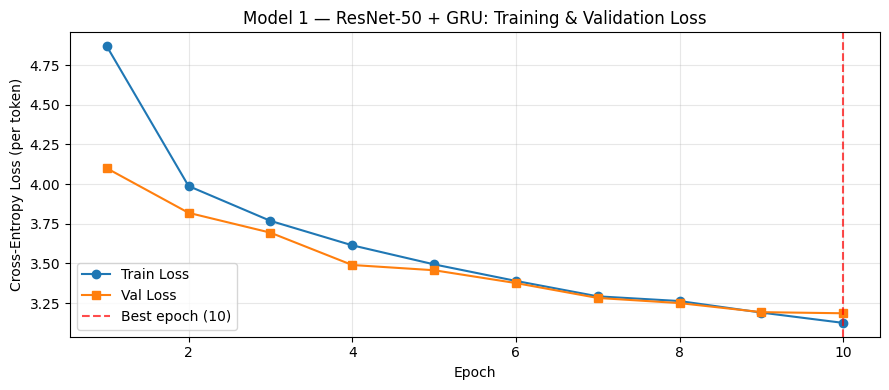

Loss curve saved.


In [22]:
fig, ax = plt.subplots(figsize=(9, 4))

epochs_x = range(1, len(history["train_loss"]) + 1)
ax.plot(epochs_x, history["train_loss"], marker="o", label="Train Loss")
ax.plot(epochs_x, history["val_loss"],   marker="s", label="Val Loss")
ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.7,
           label=f"Best epoch ({best_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss (per token)")
ax.set_title("Model 1 — ResNet-50 + GRU: Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "model1_loss_curves.png", dpi=150)
plt.show()
print("Loss curve saved.")

In [23]:
# ── Final Test Loss for Model 1 ──────────────────────────────────────────────
# Test loss is computed only after selecting the best checkpoint by validation loss.
# It is reported as held-out evidence, not used for training, scheduling, or checkpointing.

test_loss = validate_one_epoch(model, test_loss_loader, criterion, DEVICE)

print("\nModel 1 - Final Held-out Test Loss:")
print(f"  Test Loss : {test_loss:.4f}")


Model 1 - Final Held-out Test Loss:
  Test Loss : 3.1498


## 7. Evaluate Model 1 - BLEU Scores

The best checkpoint is loaded first to guarantee evaluation on the model that
generalised best during training (lowest validation loss), not the last epoch.

BLEU is computed at corpus level over the full validation and test sets.
Each predicted caption is compared against five human references per image.

In [24]:
# Load the best-epoch weights
model.load_state_dict(
    torch.load(CHECKPOINT_DIR / "model1_best.pt", map_location=DEVICE)
)
print(f"Loaded best checkpoint from epoch {best_epoch}  (val_loss = {best_val_loss:.4f})")

# ── Validation BLEU ───────────────────────────────────────────────────────────
print("\nEvaluating on Validation Set...")
val_bleu = evaluate_bleu(model, val_bleu_loader, DEVICE)

print("\nValidation BLEU Scores:")
for metric, score in val_bleu.items():
    print(f"  {metric} : {score:.4f}")

Loaded best checkpoint from epoch 10  (val_loss = 3.1863)

Evaluating on Validation Set...



Validation BLEU Scores:
  BLEU-1 : 0.5735
  BLEU-2 : 0.3967
  BLEU-3 : 0.2977
  BLEU-4 : 0.2403


In [25]:
# ── Test BLEU ────────────────────────────────────────────────────────────────
print("Evaluating on Test Set...")
test_bleu = evaluate_bleu(model, test_loader, DEVICE)

print("\nTest BLEU Scores:")
for metric, score in test_bleu.items():
    print(f"  {metric} : {score:.4f}")

Evaluating on Test Set...



Test BLEU Scores:
  BLEU-1 : 0.5764
  BLEU-2 : 0.3909
  BLEU-3 : 0.2867
  BLEU-4 : 0.2282


In [26]:
# ── Summary Table ────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    "Metric" : list(val_bleu.keys()),
    "Val"    : list(val_bleu.values()),
    "Test"   : list(test_bleu.values()),
}).set_index("Metric")

print("\n=== Model 1 — ResNet-50 + GRU  BLEU Results ===")
print(results_df.to_string())
print()

# Store results for comparison in Phase 3 (Model 2)
model1_results = {
    "architecture" : "ResNet-50 (frozen) + GRU (1 layer)",
    "embed_dim"    : EMBED_DIM,
    "hidden_dim"   : HIDDEN_DIM,
    "best_epoch"   : best_epoch,
    "best_val_loss": round(best_val_loss, 4),
    "test_loss": round(test_loss, 4),
    "val_bleu"     : val_bleu,
    "test_bleu"    : test_bleu,
}



=== Model 1 — ResNet-50 + GRU  BLEU Results ===
           Val    Test
Metric                
BLEU-1  0.5735  0.5764
BLEU-2  0.3967  0.3909
BLEU-3  0.2977  0.2867
BLEU-4  0.2403  0.2282



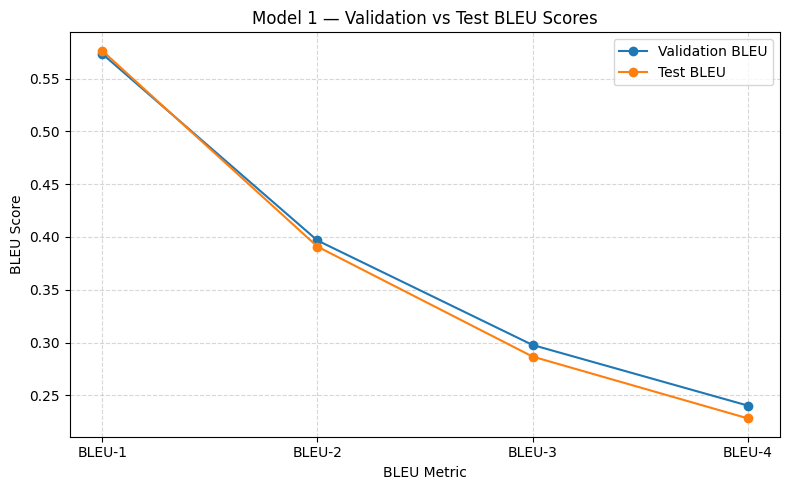

In [27]:
import matplotlib.pyplot as plt

# ── BLEU Val vs Test Line Plot ───────────────────────────────────────────────
plt.figure(figsize=(8, 5))

plt.plot(results_df.index, results_df["Val"], marker="o", label="Validation BLEU")
plt.plot(results_df.index, results_df["Test"], marker="o", label="Test BLEU")

plt.title("Model 1 — Validation vs Test BLEU Scores")
plt.xlabel("BLEU Metric")
plt.ylabel("BLEU Score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Qualitative Examples

Six validation images are shown with:
- **PRED** — caption generated by Model 1 (greedy decoding)
- **REF 1** — one of the five human-written reference captions

Visual inspection complements BLEU by revealing failure patterns that aggregate
metrics obscure (e.g. hallucinated objects, generic captions, quality-issue images).

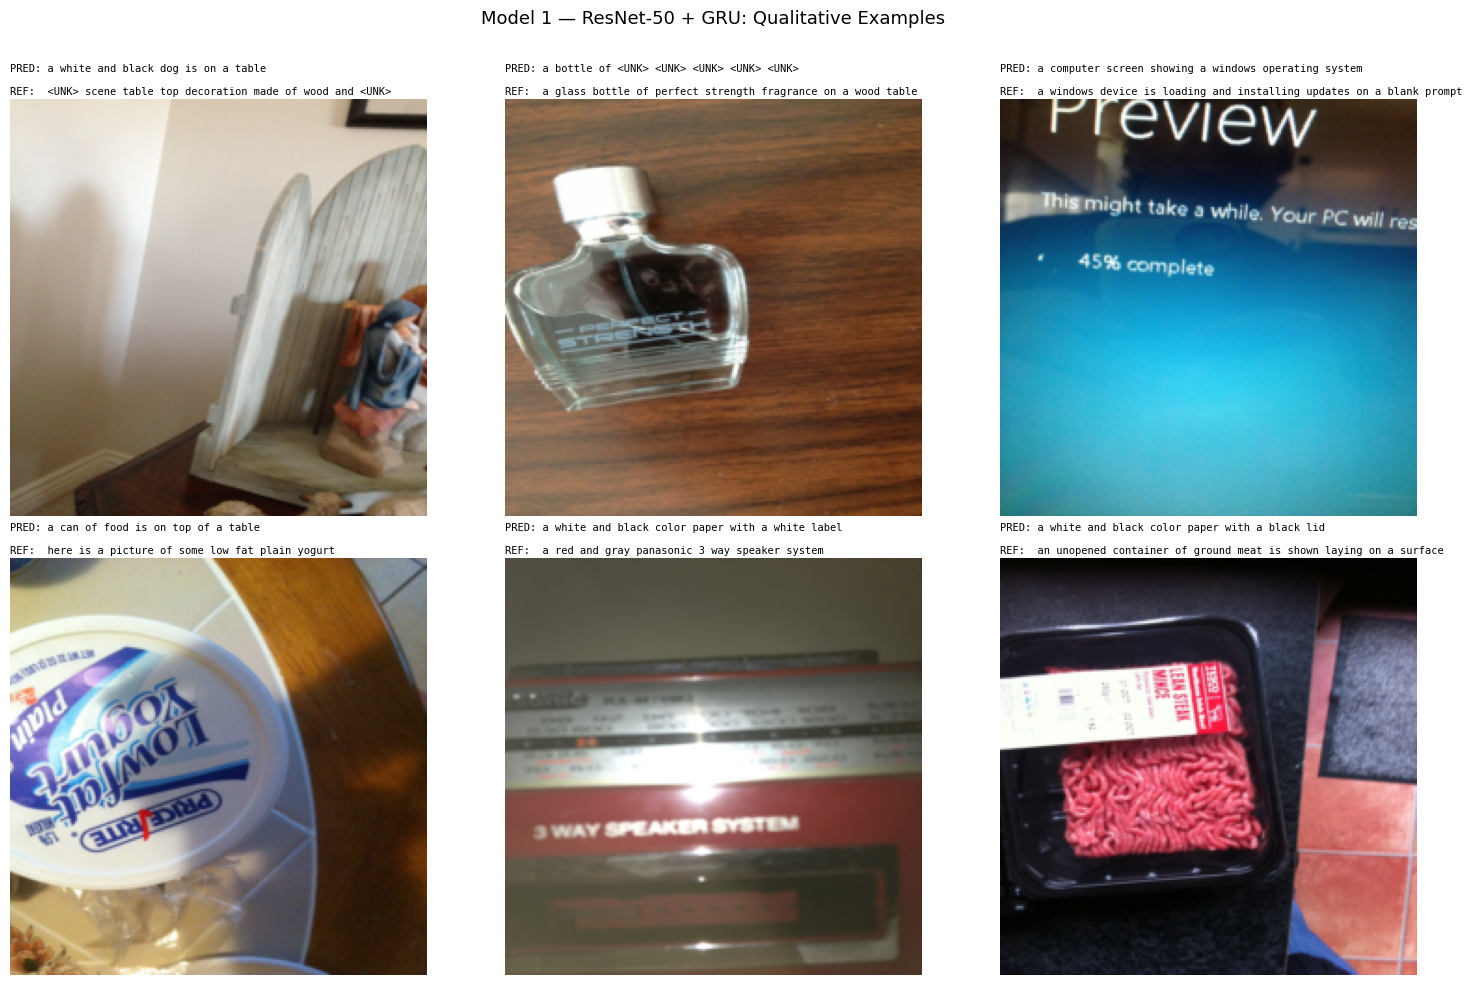

Qualitative figure saved.


In [28]:
def show_predictions(model, dataset, vocab_data, device, n=6, seed=SEED):
    """
    Display n images side-by-side with predicted and reference captions.

    Parameters
    ----------
    model    : ImageCaptioner (eval mode)
    dataset  : VizWizDataset  (training=False — has all 5 captions)
    n        : int — number of images to show
    """
    random.seed(seed)
    itos = vocab_data["itos"]
    indices = random.sample(range(len(dataset)), n)

    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
    axes = axes.flatten()

    model.eval()

    # Normalisation-free transform for display
    display_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    for plot_idx, sample_idx in enumerate(indices):
        iid, fname, encoded_caps = dataset.samples[sample_idx]
        img_path = dataset.image_dir / fname

        # Normalised tensor for the model
        norm_tensor = dataset.transform(
            Image.open(img_path).convert("RGB")
        ).unsqueeze(0).to(device)                           # (1, 3, 224, 224)

        # Generate caption (single-image greedy decode)
        with torch.no_grad():
            pred_indices = greedy_decode_batch(model, norm_tensor, device)
        predicted_words = [itos[idx] for idx in pred_indices[0]]
        predicted_str   = " ".join(predicted_words) if predicted_words else "<empty>"

        # First reference caption for display
        ref_words = [itos[t.item()] for t in encoded_caps[0]
                     if t.item() not in (PAD_IDX, SOS_IDX, EOS_IDX)]
        ref_str = " ".join(ref_words)

        # Display image (non-normalised RGB)
        raw_display = display_transform(Image.open(img_path).convert("RGB"))
        raw_display = raw_display.permute(1, 2, 0).numpy()   # H×W×C

        ax = axes[plot_idx]
        ax.imshow(raw_display)
        ax.axis("off")
        title_str = f"PRED: {predicted_str}\n\nREF:  {ref_str}"
        ax.set_title(title_str, fontsize=7.5, loc="left",
                     wrap=True, pad=4, family="monospace")

    # Hide unused axes
    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle("Model 1 — ResNet-50 + GRU: Qualitative Examples", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(CHECKPOINT_DIR / "model1_qualitative.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Qualitative figure saved.")

show_predictions(model, val_bleu_dataset, vocab_data, DEVICE, n=6)

## 9. Save Full Checkpoint

In [29]:
full_ckpt = {
    "model_state_dict"     : model.state_dict(),
    "optimizer_state_dict" : optimizer.state_dict(),
    "epoch"                : best_epoch,
    "best_val_loss"        : best_val_loss,
    "history"              : history,
    "bleu_val"             : val_bleu,
    "bleu_test"            : test_bleu,
    "hyperparameters": {
        "embed_dim"      : EMBED_DIM,
        "hidden_dim"     : HIDDEN_DIM,
        "num_gru_layers" : NUM_GRU_LAYERS,
        "learning_rate"  : LEARNING_RATE,
        "num_epochs"     : NUM_EPOCHS,
        "batch_size"     : BATCH_SIZE,
        "clip_grad_norm" : CLIP_GRAD_NORM,
        "vocab_size"     : VOCAB_SIZE,
    },
}
ckpt_path = CHECKPOINT_DIR / "model1_full_checkpoint.pt"
torch.save(full_ckpt, ckpt_path)
print(f"Full checkpoint saved to : {ckpt_path}")

Full checkpoint saved to : /Users/shreyash/Documents/Sem3DL/AT3DL/vizwiz-val-image-cap-DL-AT3/checkpoints/model1_full_checkpoint.pt


## 10. Model 1 — Limitations and Discussion

### What Model 1 gets right

- **Stable training:** Teacher forcing with a frozen backbone gives clean, monotonically
  decreasing training loss with no instability.
- **Basic visual vocabulary:** The model learns to associate common object categories
  (screens, bottles, labels) with appropriate nouns.
- **Fast iteration:** Frozen ResNet-50 means no backprop through 25 M params, so each
  epoch runs significantly faster than a fully fine-tuned model.

---

### Key limitations

**1. Single-point image injection**  
The entire image is compressed to a 512-dim vector and injected at h₀ only.
By timestep 8–10, the GRU hidden state has drifted far from the initial image signal.
The model generates plausible-sounding but visually generic captions for complex scenes.

**2. No spatial awareness**  
Global average pooling discards all positional information.
The model cannot distinguish "a cat on a table" from "a table on a cat."

**3. Teacher forcing exposure bias**  
During training the model always receives a correct previous token.
At inference it receives its own predictions.  Early errors propagate and compound,
producing repetitive or drifting captions on longer sequences.

---

### Motivation for Model 2 (Phase 3)

These observations directly motivate the changes planned for Model 2:
- **Dropout** added throughout the decoder.
- **Bahdanau soft attention** over spatial CNN feature maps (7 × 7 = 49 regions)
  so the decoder can revisit different image regions at each timestep —
  addressing limitations 1 and 2 above.

The group discussion after Phase 2 will confirm whether these patterns are
consistent across teammates' models before finalising the Model 2 design.

---

## 11. Group Discussion - What We Learned from Phase 2

Before designing Model 2, the group compared every member's Phase 2 architecture
and BLEU scores. This section documents the collective findings and how they
directly shaped Model 2's design.

### Patterns observed across all group members' Model 1 results

| Finding | Root cause | Impact |
|---|---|---|
| **Single-point image injection** — image encoded to one vector at h₀ only | No per-step visual grounding | Caption drifts away from image after a few tokens |
| **No spatial awareness** — global avg-pool discards position | All spatial information lost | Cannot distinguish "cat on a table" from "table on a cat" |
| **Teacher-forcing exposure bias** | Model never sees its own errors during training | Repetitive / drifting tokens at inference |
| **Frozen encoder / domain gap** | ImageNet ≠ VizWiz distribution | Generic object labels, misses blur/lighting context |
| **Greedy decoding** | Argmax is locally but not globally optimal | Sub-optimal sequences vs beam search |

### What this means for Model 2

The group unanimously agreed the two highest-priority fixes are:

1. **Bahdanau soft attention** over 7 × 7 spatial CNN feature maps — the decoder
   re-queries different image regions at *every* timestep instead of a single h₀ injection.
2. **Dropout (p = 0.2)** after embedding and GRU output — regularisation added; reduces overfitting on the small vocabulary.

**Additional architectural refinements identified from initial Model 2 experiments:**

- **Project encoder features 2048 → 512** inside the encoder before attention.
  Raw 2048-dim context concatenated with 256-dim embeddings gives a 2304-dim GRU
  input — too large for a 512-dim hidden state to optimise in 10 epochs.
  Projecting to 512 reduces GRU input to 768 and cuts the input-weight matrix
  size by 3×, dramatically improving convergence.
- **Doubly stochastic attention regularisation** (λ = 1.0): penalises the model
  if cumulative attention weights do not sum to 1 over each caption, preventing
  attention collapse to a single pixel.
- **15 training epochs** — attention parameters need more steps to reach a stable
  distribution than a plain GRU decoder.


## 12. Model 2 Architecture — ResNet-50 Spatial + Projection + Bahdanau Attention GRU + Dropout

```
Input image (3 × 224 × 224)
        │
        ▼
┌──────────────────────────────────────────────┐
│  ResNet-50 backbone                          │
│  → conv layer4 output: (B, 2048, 7, 7)       │
│  reshape → (B, 49, 2048)                     │
│                                              │
│  Learnable projection:                       │
│  Linear(2048 → 512) + ReLU                  │  ← KEY FIX: reduces GRU input
│  → encoder_out: (B, 49, 512)                 │    from 2304 to 768
└──────────────────────────────────────────────┘
        │  encoder_out (B, 49, 512)
        │  ┌── also used to init h₀ ─────┐
        ▼  ▼                             │
┌─────────────────────────────────────────────────────────────────┐
│  GRU Attention Decoder  (at each timestep t)                    │
│                                                                 │
│  1. Embedding(w_{t-1}) + Dropout(0.3)  → (B, 256)              │
│                                                                 │
│  2. BahdanauAttention(encoder_out, h_t):                        │
│       e_i   = v · tanh(W_enc·enc_i + W_dec·h_t)               │
│       α     = softmax(e)               → (B, 49)               │
│       ctx   = Σ α_i · enc_i           → (B, 512)               │
│                                                                 │
│  3. GRU([embed(256) ‖ ctx(512)], h_t) → h_{t+1} (B, 512)      │
│     + Dropout(0.3)                                              │
│                                                                 │
│  4. FC(h_{t+1}) → logits (B, vocab_size)                       │
└─────────────────────────────────────────────────────────────────┘
        │
        ▼
  CrossEntropyLoss(ignore PAD)
  + λ · Doubly Stochastic Attention Regularisation
```

### Design rationale — changes from initial Model 2 (and why)

| Component | Initial Model 2 | Revised Model 2 | Reason for change |
|---|---|---|---|
| Encoder output | Raw (B, 49, 2048) | Projected (B, 49, 512) | GRU input 2304→768; 3× smaller weight matrix |
| Attention dim | 256 | 512 | Larger space needed when encoder features are 512-dim |
| GRU input size | 256 + 2048 = 2304 | 256 + 512 = 768 | Main convergence fix |
| Dropout | 0.5 | 0.3 | Less aggressive; attention needs signal to learn |
| Attention reg. | None | λ = 1.0 DS reg. | Prevents attention collapse |
| Epochs | 10 | 15 | Attention needs more steps to stabilise |


In [30]:
# ── Model 2 hyperparameters: final improved Phase 3 strategy ─────────────────

EMBED_DIM2      = 256    # word embedding dimension
HIDDEN_DIM2     = 512    # GRU hidden dimension
ENCODER_PROJ2   = 512    # projected ResNet spatial feature dimension
ATTENTION_DIM2  = 512    # Bahdanau attention hidden dimension

# Priority 1:
# Lower dropout from 0.3/0.5 to 0.2.
# Reason: 0.5 can over-regularise the decoder and hurt caption fluency.
DROPOUT2        = 0.2

# Attention regularisation.
# Keep this modest. If BLEU is still weak later, try 0.5.
LAMBDA_ATT      = 1.0

# Priority 2:
# Fine-tune only the final ResNet block layer4.
# This adapts high-level visual features to VizWiz without overfitting too much.
UNFREEZE_RESNET_LAYER4 = True

# Different learning rates:
# Decoder/attention/projection learns faster.
# ResNet layer4 learns very slowly to avoid destroying pretrained ImageNet features.
DECODER_LR2 = 3e-4
ENCODER_LR2 = 1e-5

# Regularisation for trainable weights.
WEIGHT_DECAY2 = 1e-5

# Training settings
NUM_EPOCHS2     = 15
CLIP_GRAD2      = 5.0
MAX_GEN_LEN2    = 50

# Priority 3:
# Beam search usually improves BLEU compared to greedy decoding.
BEAM_SIZE2      = 3

print(f"embed={EMBED_DIM2}, hidden={HIDDEN_DIM2}, enc_proj={ENCODER_PROJ2}")
print(f"attn_dim={ATTENTION_DIM2}, dropout={DROPOUT2}, lambda_att={LAMBDA_ATT}")
print(f"decoder_lr={DECODER_LR2}, encoder_lr={ENCODER_LR2}, weight_decay={WEIGHT_DECAY2}")
print(f"epochs={NUM_EPOCHS2}, grad_clip={CLIP_GRAD2}, beam_size={BEAM_SIZE2}")
print(f"unfreeze_resnet_layer4={UNFREEZE_RESNET_LAYER4}")

embed=256, hidden=512, enc_proj=512
attn_dim=512, dropout=0.2, lambda_att=1.0
decoder_lr=0.0003, encoder_lr=1e-05, weight_decay=1e-05
epochs=15, grad_clip=5.0, beam_size=3
unfreeze_resnet_layer4=True


In [31]:
class EncoderResNet50Spatial(nn.Module):
    """
    Spatial ResNet-50 encoder with learned feature projection.

    Architecture
    ─────────────
        ResNet-50 backbone
            → (B, 2048, 7, 7)
        reshape
            → (B, 49, 2048)
        Linear(2048, projected_dim) + ReLU
            → (B, 49, projected_dim)

    Final improved Phase 3 strategy:
    - Freeze most of ResNet-50.
    - Optionally unfreeze only layer4.
    - Remove torch.no_grad() from forward() because layer4 may be trainable.
    """

    def __init__(self, projected_dim: int, unfreeze_layer4: bool = True):
        super().__init__()

        resnet = torchvision.models.resnet50(
            weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1
        )

        # Keep full ResNet blocks explicitly so we can unfreeze layer4 cleanly.
        self.stem = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
        )
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        # Freeze everything first.
        for p in self.parameters():
            p.requires_grad = False

        # Priority 2:
        # Unfreeze only the final ResNet block.
        # This gives domain adaptation without making the full CNN unstable.
        if unfreeze_layer4:
            for p in self.layer4.parameters():
                p.requires_grad = True

        # Learned projection: 2048 → projected_dim
        # This must stay trainable.
        self.projection = nn.Linear(2048, projected_dim)
        self.relu       = nn.ReLU(inplace=True)

        for p in self.projection.parameters():
            p.requires_grad = True

        self.projected_dim = projected_dim
        self.num_pixels    = 49

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        images : FloatTensor (B, 3, 224, 224)

        Returns
        -------
        features : FloatTensor (B, 49, projected_dim)
        """

        # Do NOT wrap this whole forward pass in torch.no_grad().
        # layer4 may be trainable, so gradients must flow through it.
        x = self.stem(images)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)                            # (B, 2048, 7, 7)

        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1)                     # (B, 7, 7, 2048)
        x = x.reshape(B, H * W, C)                    # (B, 49, 2048)
        x = self.relu(self.projection(x))             # (B, 49, projected_dim)

        return x

In [32]:
class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau) attention over projected spatial encoder features.

    Equations
    ---------
        e_i   = v · tanh( W_enc · enc_i  +  W_dec · h_t )   for i in {1..49}
        α     = softmax(e)                                    (B, 49)
        ctx   = Σ_i  α_i · enc_i                             (B, encoder_dim)

    Parameters
    ----------
    encoder_dim  : int — encoder feature dim (= projected_dim, 512)
    decoder_dim  : int — GRU hidden size (512)
    attention_dim: int — intermediate attention projection size (512)
    """

    def __init__(self, encoder_dim: int, decoder_dim: int, attention_dim: int):
        super().__init__()
        self.W_enc = nn.Linear(encoder_dim,  attention_dim, bias=False)
        self.W_dec = nn.Linear(decoder_dim,  attention_dim, bias=False)
        self.v     = nn.Linear(attention_dim, 1,            bias=False)

    def forward(
        self,
        encoder_out:    torch.Tensor,   # (B, num_pixels, encoder_dim)
        decoder_hidden: torch.Tensor,   # (B, decoder_dim)
    ):
        """
        Returns
        -------
        context : FloatTensor (B, encoder_dim)  — attention-weighted feature
        alpha   : FloatTensor (B, num_pixels)   — attention weights (sum to 1)
        """
        # (B, P, attn_dim) + broadcast (B, 1, attn_dim) → (B, P, attn_dim)
        energy = self.W_enc(encoder_out) + self.W_dec(decoder_hidden).unsqueeze(1)
        energy = self.v(torch.tanh(energy)).squeeze(2)         # (B, P)
        alpha  = torch.softmax(energy, dim=1)                  # (B, P)
        # Weighted context vector
        context = (alpha.unsqueeze(2) * encoder_out).sum(dim=1) # (B, encoder_dim)
        return context, alpha


In [33]:
class DecoderGRUAttention(nn.Module):
    """
    GRU caption decoder with Bahdanau attention and dropout.

    Key differences from the initial Model 2 decoder
    ─────────────────────────────────────────────────
    - GRU input = embed(256) + projected_context(512) = 768
      (was 256 + 2048 = 2304 — 3× smaller now)
    - Dropout reduced to 0.2 (was 0.5)
    - forward() returns (logits, alphas) so the training loop can apply
      doubly stochastic attention regularisation

    Parameters
    ----------
    vocab_size    : int
    embed_dim     : int   — word embedding dimension (256)
    encoder_dim   : int   — projected encoder feature dim (512)
    decoder_dim   : int   — GRU hidden size (512)
    attention_dim : int   — attention projection size (512)
    pad_idx       : int
    dropout       : float - default 0.2
    """

    def __init__(
        self,
        vocab_size:    int,
        embed_dim:     int,
        encoder_dim:   int,
        decoder_dim:   int,
        attention_dim: int,
        pad_idx:       int,
        dropout:       float = 0.2,
    ):
        super().__init__()
        self.decoder_dim = decoder_dim
        self.encoder_dim = encoder_dim

        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.attention  = BahdanauAttention(encoder_dim, decoder_dim, attention_dim)

        # GRU input = [word_embedding (E) ‖ context (C)] — 256 + 512 = 768
        self.gru        = nn.GRU(embed_dim + encoder_dim, decoder_dim, batch_first=True)

        self.drop_emb   = nn.Dropout(dropout)   # after embedding
        self.drop_out   = nn.Dropout(dropout)   # after GRU output
        self.fc         = nn.Linear(decoder_dim, vocab_size)

        # h₀: map mean encoder features to initial GRU hidden state
        self.init_h_fc  = nn.Linear(encoder_dim, decoder_dim)

    def _init_hidden(self, encoder_out: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        encoder_out : FloatTensor (B, num_pixels, encoder_dim)

        Returns
        -------
        h0 : FloatTensor (1, B, decoder_dim)
        """
        mean_enc = encoder_out.mean(dim=1)              # (B, encoder_dim)
        h0 = torch.tanh(self.init_h_fc(mean_enc))      # (B, decoder_dim)
        return h0.unsqueeze(0)                          # (1, B, decoder_dim)

    def forward(
        self,
        encoder_out: torch.Tensor,   # (B, num_pixels, encoder_dim)
        captions:    torch.Tensor,   # (B, T)  decoder input (SOS … w_N)
    ):
        """
        Teacher-forcing forward pass.

        Returns
        -------
        logits : FloatTensor (B, T, vocab_size)
        alphas : FloatTensor (B, T, num_pixels)   — attention weights per timestep
                 Used by training loop for doubly stochastic regularisation.
        """
        B, T = captions.shape
        embeddings = self.drop_emb(self.embedding(captions))   # (B, T, embed_dim)
        h = self._init_hidden(encoder_out)                     # (1, B, decoder_dim)

        logit_list = []
        alpha_list = []

        for t in range(T):
            emb_t = embeddings[:, t, :].unsqueeze(1)           # (B, 1, embed_dim)

            # Recompute attention context at every timestep
            context, alpha = self.attention(
                encoder_out, h.squeeze(0)
            )                                                   # (B, enc_dim), (B, P)

            gru_in = torch.cat([emb_t, context.unsqueeze(1)], dim=2)  # (B,1,E+C)
            out, h = self.gru(gru_in, h)                       # (B, 1, dec_dim)

            out = self.drop_out(out.squeeze(1))                 # (B, dec_dim)
            logit_list.append(self.fc(out))                     # (B, vocab_size)
            alpha_list.append(alpha)                            # (B, num_pixels)

        logits = torch.stack(logit_list, dim=1)                 # (B, T, vocab_size)
        alphas = torch.stack(alpha_list, dim=1)                 # (B, T, num_pixels)
        return logits, alphas


In [34]:
class ImageCaptionerV2(nn.Module):
    """
    Full Model 2: projected spatial ResNet-50 encoder + attention GRU decoder.

    forward() returns (logits, alphas) — the training loop uses alphas for
    doubly stochastic attention regularisation.
    """

    def __init__(
        self,
        encoder: EncoderResNet50Spatial,
        decoder: DecoderGRUAttention,
    ):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        images:   torch.Tensor,   # (B, 3, 224, 224)
        captions: torch.Tensor,   # (B, T)  — full caption incl. SOS and EOS
    ):
        """
        Returns
        -------
        logits : FloatTensor (B, T-1, vocab_size)
        alphas : FloatTensor (B, T-1, num_pixels)
            Decoder input  = captions[:, :-1]  →  SOS, w₁, …, w_{N}
            Decoder target = captions[:, 1:]   →  w₁, …, w_{N}, EOS
        """
        encoder_out = self.encoder(images)                      # (B, 49, enc_proj)
        logits, alphas = self.decoder(encoder_out, captions[:, :-1])
        return logits, alphas


In [35]:
# ── Build Model 2 ─────────────────────────────────────────────────────────────

encoder2 = EncoderResNet50Spatial(
    projected_dim=ENCODER_PROJ2,
    unfreeze_layer4=UNFREEZE_RESNET_LAYER4,
)

decoder2 = DecoderGRUAttention(
    vocab_size    = VOCAB_SIZE,
    embed_dim     = EMBED_DIM2,
    encoder_dim   = ENCODER_PROJ2,
    decoder_dim   = HIDDEN_DIM2,
    attention_dim = ATTENTION_DIM2,
    pad_idx       = PAD_IDX,
    dropout       = DROPOUT2,
)

model2 = ImageCaptionerV2(encoder2, decoder2).to(DEVICE)

# ── Parameter count ───────────────────────────────────────────────────────────
total2     = sum(p.numel() for p in model2.parameters())
trainable2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)
frozen2    = total2 - trainable2

print(f"{'Total parameters':<45}: {total2:>12,}")
print(f"{'Trainable parameters':<45}: {trainable2:>12,}")
print(f"{'Frozen parameters':<45}: {frozen2:>12,}")
print(f"\nModel on device : {next(model2.parameters()).device}")

print("\nComponent breakdown:")
for name, module in model2.named_children():
    n = sum(p.numel() for p in module.parameters())
    t = sum(p.numel() for p in module.parameters() if p.requires_grad)
    print(f"  {name:<12}  total={n:>12,}   trainable={t:>12,}")

print("\nEncoder trainability check:")
for name, param in model2.encoder.named_parameters():
    if param.requires_grad:
        print(f"  TRAINABLE: encoder.{name}")

# ── Quick sanity-check: one forward pass ──────────────────────────────────────
model2.eval()
_imgs  = torch.zeros(2, 3, 224, 224, device=DEVICE)
_caps  = torch.ones(2, 10, dtype=torch.long, device=DEVICE)

with torch.no_grad():
    _logits, _alphas = model2(_imgs, _caps)

print(f"\nSanity check — logits shape : {_logits.shape}")   # (2, 9, vocab_size)
print(f"Sanity check — alphas shape : {_alphas.shape}")    # (2, 9, 49)

assert _alphas.shape[-1] == encoder2.num_pixels, "Attention dim mismatch!"
assert abs(_alphas[0, 0].sum().item() - 1.0) < 1e-4, "Attention does not sum to 1!"

print("All sanity checks passed.")

del _imgs, _caps, _logits, _alphas

Total parameters                             :   29,831,434
Trainable parameters                         :   21,288,138
Frozen parameters                            :    8,543,296

Model on device : mps:0

Component breakdown:
  encoder       total=  24,557,120   trainable=  16,013,824
  decoder       total=   5,274,314   trainable=   5,274,314

Encoder trainability check:
  TRAINABLE: encoder.layer4.0.conv1.weight
  TRAINABLE: encoder.layer4.0.bn1.weight
  TRAINABLE: encoder.layer4.0.bn1.bias
  TRAINABLE: encoder.layer4.0.conv2.weight
  TRAINABLE: encoder.layer4.0.bn2.weight
  TRAINABLE: encoder.layer4.0.bn2.bias
  TRAINABLE: encoder.layer4.0.conv3.weight
  TRAINABLE: encoder.layer4.0.bn3.weight
  TRAINABLE: encoder.layer4.0.bn3.bias
  TRAINABLE: encoder.layer4.0.downsample.0.weight
  TRAINABLE: encoder.layer4.0.downsample.1.weight
  TRAINABLE: encoder.layer4.0.downsample.1.bias
  TRAINABLE: encoder.layer4.1.conv1.weight
  TRAINABLE: encoder.layer4.1.bn1.weight
  TRAINABLE: encoder.la

## 13. Model 2 — Training Setup

Two new training functions are needed because Model 2's `forward()` returns
`(logits, alphas)` and we add a doubly stochastic attention regularisation term.

### Doubly stochastic attention regularisation

From *Show, Attend and Tell* (Xu et al., 2015): if the model attends to each of
the 49 image pixels equally over a full caption, the sum of attention weights
across all timesteps should be close to 1 for every pixel.

```
L_total = L_CE  +  λ · mean_batch[ (1 − Σ_t α_t)² ]
```

- `Σ_t α_t` : sum of attention weight for each pixel across all T timesteps — shape (B, 49)
- Penalises the model if any pixel is ignored (sum → 0) or over-attended (sum >> 1)
- λ = 1.0 recommended in the original paper; we use the same value

| Component | Value |
|---|---|
| Loss | CrossEntropyLoss (ignore PAD) + DS attention reg. (λ=1.0) |
| Optimiser | Adam, lr = 3e-4 |
| Scheduler | ReduceLROnPlateau (×0.5, patience=2) |
| Grad clip | L2 norm ≤ 5.0 |
| Checkpoint | Best val loss → `model2_best.pt` |


In [36]:
criterion2 = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# ── Optimizer with separate learning rates ───────────────────────────────────
# Priority 2:
# encoder.layer4 gets a very small LR.
# decoder + attention + projection get the normal LR.

encoder_finetune_params = list(model2.encoder.layer4.parameters())
encoder_finetune_param_ids = {id(p) for p in encoder_finetune_params}

main_params = [
    p for p in model2.parameters()
    if p.requires_grad and id(p) not in encoder_finetune_param_ids
]

optimizer2 = optim.Adam(
    [
        {
            "params": main_params,
            "lr": DECODER_LR2,
            "name": "decoder_attention_projection",
        },
        {
            "params": encoder_finetune_params,
            "lr": ENCODER_LR2,
            "name": "resnet_layer4",
        },
    ],
    weight_decay=WEIGHT_DECAY2,
)

# Priority 5:
# Reduce LR when validation loss stops improving.
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2,
    mode="min",
    factor=0.5,
    patience=2,
)

print(f"Criterion  : CrossEntropyLoss(ignore_index=PAD) + λ={LAMBDA_ATT} DS-Attn Reg")
print(f"Optimiser  : Adam with separate learning rates")
print(f"  main params lr      : {DECODER_LR2}")
print(f"  ResNet layer4 lr    : {ENCODER_LR2}")
print(f"  weight decay        : {WEIGHT_DECAY2}")
print(f"Scheduler  : ReduceLROnPlateau(factor=0.5, patience=2)")
print(f"Grad clip  : {CLIP_GRAD2}")

print("\nOptimizer parameter groups:")
for group in optimizer2.param_groups:
    n_params = sum(p.numel() for p in group["params"])
    print(f"  {group.get('name', 'group'):<30} lr={group['lr']:.1e} params={n_params:,}")

Criterion  : CrossEntropyLoss(ignore_index=PAD) + λ=1.0 DS-Attn Reg
Optimiser  : Adam with separate learning rates
  main params lr      : 0.0003
  ResNet layer4 lr    : 1e-05
  weight decay        : 1e-05
Scheduler  : ReduceLROnPlateau(factor=0.5, patience=2)
Grad clip  : 5.0

Optimizer parameter groups:
  decoder_attention_projection   lr=3.0e-04 params=6,323,402
  resnet_layer4                  lr=1.0e-05 params=14,964,736


In [37]:
def train_one_epoch_v2(model2, loader, criterion, optimizer, device,
                       clip_grad_norm, lambda_att=1.0):
    """
    One training epoch for ImageCaptionerV2 with attention regularisation.

    Steps per batch
    ───────────────
    1. Encode images → projected spatial features.
    2. Decode with teacher forcing → logits (B, T-1, V) and alphas (B, T-1, P).
    3. Cross-entropy loss on logits (PAD ignored).
    4. Doubly stochastic attention penalty: λ · mean[(1 − Σ_t α_t)²].
    5. Backpropagate total loss; clip gradients; update weights.

    Parameters
    ----------
    model2       : ImageCaptionerV2
    loader       : DataLoader (training=True, collate_train)
    criterion    : CrossEntropyLoss
    optimizer    : Adam
    device       : torch.device
    clip_grad_norm: float
    lambda_att   : float — attention regularisation weight (default 1.0)

    Returns
    -------
    avg_loss : float — per-token CE loss averaged over the epoch (excludes reg.)
    """
    model2.train()
    total_ce_loss  = 0.0
    total_tokens   = 0

    for images, captions, lengths in tqdm(loader, desc="  Train", leave=False):
        images   = images.to(device)
        captions = captions.to(device)                         # (B, T)

        optimizer.zero_grad()

        # ── Forward ───────────────────────────────────────────────────────
        logits, alphas = model2(images, captions)              # (B,T-1,V), (B,T-1,P)
        targets = captions[:, 1:]                              # (B, T-1)
        B, T, V = logits.shape

        # ── Cross-entropy loss (ignore PAD) ───────────────────────────────
        ce_loss = criterion(logits.reshape(B * T, V), targets.reshape(B * T))

        # ── Doubly stochastic attention regularisation ────────────────────
        # alphas: (B, T-1, P=49) → sum over timesteps → (B, P)
        # Ideal: each pixel attended to exactly once → sum = 1
        alpha_sum = alphas.sum(dim=1)                          # (B, P)
        ds_reg    = lambda_att * ((1.0 - alpha_sum) ** 2).mean()

        loss = ce_loss + ds_reg

        # ── Backward ──────────────────────────────────────────────────────
        loss.backward()
        nn.utils.clip_grad_norm_([p for p in model2.parameters() if p.requires_grad],
                                 max_norm=clip_grad_norm)
        optimizer.step()

        # Track CE loss separately (excludes reg. term) for comparability
        non_pad       = (targets != PAD_IDX).sum().item()
        total_ce_loss += ce_loss.item() * non_pad
        total_tokens  += non_pad

    return total_ce_loss / total_tokens


def validate_one_epoch_v2(model2, loader, criterion, device):
    """
    Validation loss for ImageCaptionerV2.
    Uses teacher forcing (no weight updates).
    Returns per-token CE loss (no attention reg.) for scheduler compatibility.
    """
    model2.eval()
    total_loss   = 0.0
    total_tokens = 0

    with torch.no_grad():
        for images, captions, lengths in tqdm(loader, desc="   Val", leave=False):
            images   = images.to(device)
            captions = captions.to(device)

            logits, _ = model2(images, captions)               # ignore alphas for val
            targets   = captions[:, 1:]
            B, T, V   = logits.shape

            loss = criterion(logits.reshape(B * T, V), targets.reshape(B * T))

            non_pad      = (targets != PAD_IDX).sum().item()
            total_loss  += loss.item() * non_pad
            total_tokens += non_pad

    return total_loss / total_tokens


## 14. Train Model 2

Each epoch:
1. **Train** — full pass over 5,425 training images with teacher forcing + attention reg.
2. **Validate** — CE loss on 1,162 validation images (no attention reg., for fair scheduler).
3. **Scheduler step** — halve LR if val loss did not improve for 2 consecutive epochs.
4. **Checkpoint** — save weights if val loss is the best seen so far.

The best checkpoint is loaded before BLEU evaluation in Section 15.


In [38]:
history2       = {"train_loss": [], "val_loss": []}
best_val_loss2 = float("inf")
best_epoch2    = 0

print("=" * 64)
print("Training : ResNet-50 + Bahdanau Attention GRU + Dropout")
print(f"Epochs   : {NUM_EPOCHS2}")
print(f"Decoder LR / Main LR : {DECODER_LR2}")
print(f"Encoder layer4 LR    : {ENCODER_LR2}")
print(f"Batch    : {BATCH_SIZE}")
print(f"Device   : {DEVICE}")
print(f"Attn reg : lambda={LAMBDA_ATT}")
print("=" * 64)

for epoch in range(1, NUM_EPOCHS2 + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS2}")

    train_loss = train_one_epoch_v2(
        model2, train_loader, criterion2, optimizer2,
        DEVICE, CLIP_GRAD2, LAMBDA_ATT,
    )

    val_loss = validate_one_epoch_v2(
        model2, val_loss_loader, criterion2, DEVICE
    )

    scheduler2.step(val_loss)
    current_lr = optimizer2.param_groups[0]["lr"]

    history2["train_loss"].append(train_loss)
    history2["val_loss"].append(val_loss)

    print(f"  Train Loss : {train_loss:.4f}  |  Val Loss : {val_loss:.4f}"
          f"  |  LR : {current_lr:.2e}")

    if val_loss < best_val_loss2:
        best_val_loss2 = val_loss
        best_epoch2    = epoch
        torch.save(model2.state_dict(), CHECKPOINT_DIR / "model2_best.pt")
        print(f"  Best model saved  (val_loss = {best_val_loss2:.4f})")

print(f"\nTraining complete.")
print(f"Best val loss : {best_val_loss2:.4f}  at epoch {best_epoch2}")


Training : ResNet-50 + Bahdanau Attention GRU + Dropout
Epochs   : 15
Decoder LR / Main LR : 0.0003
Encoder layer4 LR    : 1e-05
Batch    : 32
Device   : mps
Attn reg : lambda=1.0

Epoch 1/15


  Train Loss : 4.8887  |  Val Loss : 4.1714  |  LR : 3.00e-04
  Best model saved  (val_loss = 4.1714)

Epoch 2/15


  Train Loss : 4.1398  |  Val Loss : 3.8541  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.8541)

Epoch 3/15


  Train Loss : 3.8435  |  Val Loss : 3.6405  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.6405)

Epoch 4/15


  Train Loss : 3.6710  |  Val Loss : 3.4949  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.4949)

Epoch 5/15


...

  Train Loss : 3.1153  |  Val Loss : 3.1405  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.1405)

Epoch 12/15


  Train Loss : 3.0683  |  Val Loss : 3.1356  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.1356)

Epoch 13/15


  Train Loss : 3.0262  |  Val Loss : 3.1046  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.1046)

Epoch 14/15


  Train Loss : 2.9756  |  Val Loss : 3.1216  |  LR : 3.00e-04

Epoch 15/15


  Train Loss : 2.9467  |  Val Loss : 3.0670  |  LR : 3.00e-04
  Best model saved  (val_loss = 3.0670)

Training complete.
Best val loss : 3.0670  at epoch 15


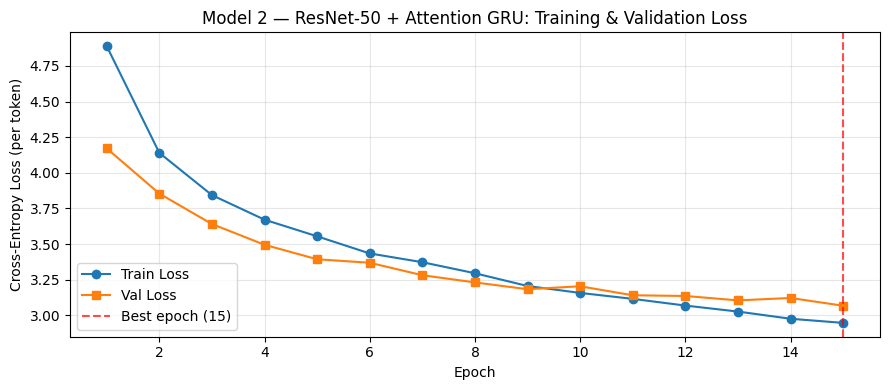

Loss curve saved.


In [39]:
fig, ax = plt.subplots(figsize=(9, 4))

epochs_x = range(1, len(history2["train_loss"]) + 1)
ax.plot(epochs_x, history2["train_loss"], marker="o", label="Train Loss")
ax.plot(epochs_x, history2["val_loss"],   marker="s", label="Val Loss")
ax.axvline(best_epoch2, color="red", linestyle="--", alpha=0.7,
           label=f"Best epoch ({best_epoch2})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss (per token)")
ax.set_title("Model 2 — ResNet-50 + Attention GRU: Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "model2_loss_curves.png", dpi=150)
plt.show()
print("Loss curve saved.")


## 15. Evaluate Model 2 — BLEU Scores

Greedy decoding runs the attention mechanism step-by-step at inference —
context is recomputed at every token using the current GRU hidden state.
The rest of the evaluation pipeline (multi-reference BLEU, smoothing) is
identical to Model 1.


In [40]:
def greedy_decode_v2(model2, images, device, max_len=MAX_GEN_LEN2):
    """
    Greedy decoding for ImageCaptionerV2.
    Kept for comparison, but final BLEU should use beam search.
    """
    model2.eval()
    B = images.size(0)

    encoder_out = model2.encoder(images)
    h = model2.decoder._init_hidden(encoder_out)

    current_tokens = torch.full(
        (B,), SOS_IDX, dtype=torch.long, device=device
    )

    generated = [[] for _ in range(B)]
    finished  = [False] * B

    for _ in range(max_len):
        emb = model2.decoder.embedding(current_tokens.unsqueeze(1))

        context, _ = model2.decoder.attention(
            encoder_out, h.squeeze(0)
        )

        gru_in = torch.cat([emb, context.unsqueeze(1)], dim=2)
        out, h = model2.decoder.gru(gru_in, h)

        logits = model2.decoder.fc(out.squeeze(1))
        preds  = logits.argmax(dim=-1)

        for i in range(B):
            if finished[i]:
                continue

            pred = preds[i].item()

            if pred == EOS_IDX:
                finished[i] = True
            elif pred not in (PAD_IDX, SOS_IDX):
                generated[i].append(pred)

        if all(finished):
            break

        current_tokens = preds

    return generated


def beam_search_decode_single_v2(model2, image, device, beam_size=3, max_len=MAX_GEN_LEN2):
    """
    Beam search decoding for one image.

    Why this helps:
    Greedy decoding chooses the best word at each step locally.
    Beam search keeps multiple candidate captions and usually gives better BLEU.

    Parameters
    ----------
    image : FloatTensor (3, 224, 224), already normalised
    """

    model2.eval()

    with torch.no_grad():
        image = image.unsqueeze(0).to(device)                  # (1, 3, 224, 224)

        encoder_out = model2.encoder(image)                    # (1, 49, enc_dim)
        h0 = model2.decoder._init_hidden(encoder_out)          # (1, 1, dec_dim)

        # Each beam item:
        # (tokens_generated_so_far, hidden_state, log_probability, finished_flag)
        beams = [
            (
                [SOS_IDX],
                h0,
                0.0,
                False,
            )
        ]

        for _ in range(max_len):
            candidates = []

            for tokens, h, score, finished in beams:
                if finished:
                    candidates.append((tokens, h, score, finished))
                    continue

                current_token = torch.tensor(
                    [tokens[-1]], dtype=torch.long, device=device
                )

                emb = model2.decoder.embedding(current_token.unsqueeze(1))

                context, _ = model2.decoder.attention(
                    encoder_out, h.squeeze(0)
                )

                gru_in = torch.cat([emb, context.unsqueeze(1)], dim=2)
                out, h_new = model2.decoder.gru(gru_in, h)

                logits = model2.decoder.fc(out.squeeze(1))
                log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)

                top_log_probs, top_indices = torch.topk(log_probs, beam_size)

                for log_p, idx in zip(top_log_probs, top_indices):
                    idx = idx.item()
                    new_score = score + log_p.item()
                    new_tokens = tokens + [idx]
                    new_finished = idx == EOS_IDX

                    candidates.append(
                        (
                            new_tokens,
                            h_new,
                            new_score,
                            new_finished,
                        )
                    )

            # Length-normalised beam ranking.
            # This prevents the model from preferring very short captions.
            def normalised_score(candidate):
                tokens, _, score, _ = candidate
                length = max(len(tokens) - 1, 1)
                return score / length

            beams = sorted(
                candidates,
                key=normalised_score,
                reverse=True,
            )[:beam_size]

            if all(finished for _, _, _, finished in beams):
                break

        best_tokens = beams[0][0]

        # Remove SOS/EOS/PAD from final output.
        cleaned = [
            t for t in best_tokens
            if t not in (PAD_IDX, SOS_IDX, EOS_IDX)
        ]

        return cleaned


def beam_search_decode_batch_v2(model2, images, device, beam_size=BEAM_SIZE2, max_len=MAX_GEN_LEN2):
    """
    Beam search for a batch.

    For simplicity and correctness, beam search is applied image-by-image.
    This is slower than greedy decoding but better for final BLEU reporting.
    """
    generated = []

    for i in range(images.size(0)):
        pred = beam_search_decode_single_v2(
            model2=model2,
            image=images[i],
            device=device,
            beam_size=beam_size,
            max_len=max_len,
        )
        generated.append(pred)

    return generated


def evaluate_bleu_v2(model2, loader, device, max_len=MAX_GEN_LEN2, use_beam=True, beam_size=BEAM_SIZE2):
    """
    Corpus-level BLEU-1..4 for Model 2.

    use_beam=True:
        Uses beam search decoding for final BLEU reporting.

    use_beam=False:
        Uses greedy decoding for comparison/debugging.
    """
    model2.eval()
    itos = vocab_data["itos"]

    all_references = []
    all_hypotheses = []

    decode_name = f"BLEU-v2 beam={beam_size}" if use_beam else "BLEU-v2 greedy"

    with torch.no_grad():
        for images, all_captions, all_lengths in tqdm(loader, desc=decode_name):
            images = images.to(device)
            B = images.size(0)

            if use_beam:
                pred_indices = beam_search_decode_batch_v2(
                    model2,
                    images,
                    device,
                    beam_size=beam_size,
                    max_len=max_len,
                )
            else:
                pred_indices = greedy_decode_v2(
                    model2,
                    images,
                    device,
                    max_len=max_len,
                )

            for i in range(B):
                hyp = [itos[idx] for idx in pred_indices[i]]
                all_hypotheses.append(hyp)

                refs = []
                for cap_tensor in all_captions[i]:
                    ref_words = [
                        itos[t.item()]
                        for t in cap_tensor
                        if t.item() not in (PAD_IDX, SOS_IDX, EOS_IDX)
                    ]
                    refs.append(ref_words)

                all_references.append(refs)

    sf = SmoothingFunction().method1

    scores = {
        "BLEU-1": corpus_bleu(
            all_references,
            all_hypotheses,
            weights=(1, 0, 0, 0),
            smoothing_function=sf,
        ),
        "BLEU-2": corpus_bleu(
            all_references,
            all_hypotheses,
            weights=(0.5, 0.5, 0, 0),
            smoothing_function=sf,
        ),
        "BLEU-3": corpus_bleu(
            all_references,
            all_hypotheses,
            weights=(1/3, 1/3, 1/3, 0),
            smoothing_function=sf,
        ),
        "BLEU-4": corpus_bleu(
            all_references,
            all_hypotheses,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=sf,
        ),
    }

    return {k: round(v, 4) for k, v in scores.items()}

In [ ]:
# Load best-epoch weights before evaluation
model2.load_state_dict(
    torch.load(CHECKPOINT_DIR / "model2_best.pt", map_location=DEVICE)
)

print(f"Loaded best checkpoint from epoch {best_epoch2}"
      f"  (val_loss = {best_val_loss2:.4f})")

# ── Validation BLEU: Greedy for comparison ───────────────────────────────────
print("\nEvaluating Model 2 on Validation Set using GREEDY decoding...")
val_bleu2_greedy = evaluate_bleu_v2(
    model2,
    val_bleu_loader,
    DEVICE,
    use_beam=False,
)

print("\nValidation BLEU Scores — Greedy:")
for metric, score in val_bleu2_greedy.items():
    print(f"  {metric} : {score:.4f}")

# ── Validation BLEU: Beam search final ───────────────────────────────────────
print(f"\nEvaluating Model 2 on Validation Set using BEAM SEARCH beam={BEAM_SIZE2}...")
val_bleu2 = evaluate_bleu_v2(
    model2,
    val_bleu_loader,
    DEVICE,
    use_beam=True,
    beam_size=BEAM_SIZE2,
)

print("\nValidation BLEU Scores — Beam Search:")
for metric, score in val_bleu2.items():
    print(f"  {metric} : {score:.4f}")

# ── Test BLEU: Greedy for comparison ───────────────────────
print("\nEvaluating Model 2 on Test Set using GREEDY decoding...")
test_bleu2_greedy = evaluate_bleu_v2(
    model2,
    test_loader,
    DEVICE,
    use_beam=False,
)

print("\nTest BLEU Scores — Greedy:")
for metric, score in test_bleu2_greedy.items():
    print(f"  {metric} : {score:.4f}")

# ── Test BLEU: Beam search final ─────────────────────────────────────────────
print(f"\nEvaluating Model 2 on Test Set using BEAM SEARCH beam={BEAM_SIZE2}...")
test_bleu2 = evaluate_bleu_v2(
    model2,
    test_loader,
    DEVICE,
    use_beam=True,
    beam_size=BEAM_SIZE2,
)

print("\nTest BLEU Scores — Beam Search:")
for metric, score in test_bleu2.items():
    print(f"  {metric} : {score:.4f}")

# ── Final Test Loss for Model 2 ──────────────────────────────────────────────
test_loss2 = validate_one_epoch_v2(
    model2,
    test_loss_loader,
    criterion2,
    DEVICE,
)

print("\nModel 2 - Final Held-out Test Loss:")
print(f"  Test Loss : {test_loss2:.4f}")

# Store results
model2_results = {
    "architecture" : "ResNet-50 layer4 fine-tuned + projected spatial features + Bahdanau Attention GRU + dropout=0.2",
    "embed_dim"    : EMBED_DIM2,
    "hidden_dim"   : HIDDEN_DIM2,
    "encoder_proj" : ENCODER_PROJ2,
    "attention_dim": ATTENTION_DIM2,
    "dropout"      : DROPOUT2,
    "lambda_att"   : LAMBDA_ATT,
    "decoder_lr"   : DECODER_LR2,
    "encoder_lr"   : ENCODER_LR2,
    "weight_decay" : WEIGHT_DECAY2,
    "beam_size"    : BEAM_SIZE2,
    "best_epoch"   : best_epoch2,
    "best_val_loss": round(best_val_loss2, 4),
    "test_loss"    : round(test_loss2, 4),
    "val_bleu_greedy": val_bleu2_greedy,
    "val_bleu"     : val_bleu2,
    "test_bleu_greedy": test_bleu2_greedy,
    "test_bleu_beam"  : test_bleu2,
}

Loaded best checkpoint from epoch 15  (val_loss = 3.0670)

Evaluating Model 2 on Validation Set using GREEDY decoding...


BLEU-v2 greedy: 100%|██████████| 37/37 [00:22<00:00,  1.63it/s]



Validation BLEU Scores — Greedy:
  BLEU-1 : 0.5560
  BLEU-2 : 0.4048
  BLEU-3 : 0.3011
  BLEU-4 : 0.2346

Evaluating Model 2 on Validation Set using BEAM SEARCH beam=3...


BLEU-v2 beam=3: 100%|██████████| 37/37 [01:33<00:00,  2.52s/it]



Validation BLEU Scores — Beam Search:
  BLEU-1 : 0.5910
  BLEU-2 : 0.4761
  BLEU-3 : 0.3991
  BLEU-4 : 0.3474

Evaluating Model 2 on Test Set using GREEDY decoding...


BLEU-v2 greedy: 100%|██████████| 37/37 [00:20<00:00,  1.82it/s]



Test BLEU Scores — Greedy:
  BLEU-1 : 0.5663
  BLEU-2 : 0.4081
  BLEU-3 : 0.2991
  BLEU-4 : 0.2311

Evaluating Model 2 on Test Set using BEAM SEARCH beam=3...


BLEU-v2 beam=3: 100%|██████████| 37/37 [01:31<00:00,  2.48s/it]



Test BLEU Scores — Beam Search:
  BLEU-1 : 0.5829
  BLEU-2 : 0.4652
  BLEU-3 : 0.3877
  BLEU-4 : 0.3371



Model 2 - Final Held-out Test Loss:
  Test Loss : 3.0433


In [42]:
print("\n=== Loss Comparison ===")
print(f"Model 1 best val loss : {model1_results['best_val_loss']:.4f}"
      f"  (epoch {model1_results['best_epoch']})")
print(f"Model 2 best val loss : {model2_results['best_val_loss']:.4f}"
      f"  (epoch {model2_results['best_epoch']})")

print(f"\nModel 1 test loss     : {model1_results['test_loss']:.4f}")
print(f"Model 2 test loss     : {model2_results['test_loss']:.4f}")


=== Loss Comparison ===
Model 1 best val loss : 3.1863  (epoch 10)
Model 2 best val loss : 3.0670  (epoch 15)

Model 1 test loss     : 3.1498
Model 2 test loss     : 3.0433


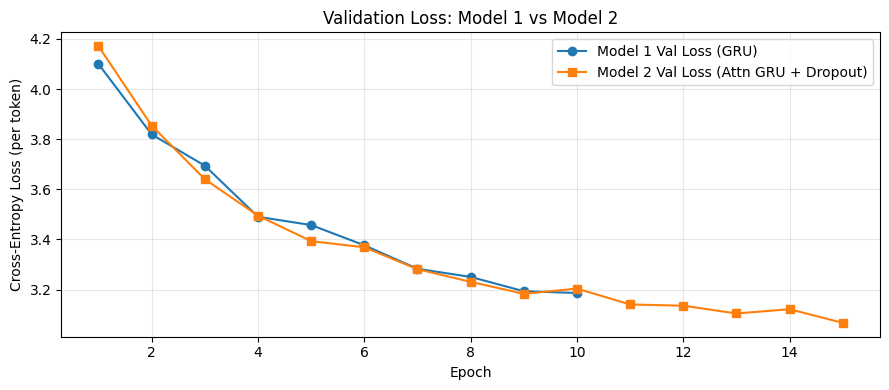

Loss comparison chart saved.


In [43]:
# ── Val loss overlay ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
e1 = range(1, len(history["val_loss"])  + 1)
e2 = range(1, len(history2["val_loss"]) + 1)
ax.plot(e1, history["val_loss"],  marker="o", label="Model 1 Val Loss (GRU)")
ax.plot(e2, history2["val_loss"], marker="s", label="Model 2 Val Loss (Attn GRU + Dropout)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss (per token)")
ax.set_title("Validation Loss: Model 1 vs Model 2")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "val_loss_comparison.png", dpi=150)
plt.show()
print("Loss comparison chart saved.")

## 16. Model 1 vs Model 2 - Comparison

Both models use the same dataset split, image resolution, vocabulary and batch size. 

Model 2 has separate learning rates, fine-tuned ResNet layer4, greedy decoding for controlled comparison, and beam search as the final decoding strategy.

Also, Model 2 was trained for 15 epochs compared with 10 epochs for Model 1 and also adds attention regularisation and dropout. Therefore, the improvement should be interpreted as the combined effect of the refined Phase 3 architecture, regularisation strategy, and longer training schedule, not architecture alone.


In [44]:
# ── Validation BLEU Comparison: Model 1 vs Model 2 Greedy ───────────────
m1_val = model1_results["val_bleu"]
m2_val_greedy = model2_results["val_bleu_greedy"]

comparison_val_df = pd.DataFrame({
    "Metric": list(m1_val.keys()),
    "Model 1 (ResNet-50 + GRU)": [m1_val[m] for m in m1_val.keys()],
    "Model 2 (ResNet-50 + Attention GRU, Greedy)": [m2_val_greedy[m] for m in m1_val.keys()],
}).set_index("Metric")

comparison_val_df["Δ (abs)"] = (
    comparison_val_df["Model 2 (ResNet-50 + Attention GRU, Greedy)"] -
    comparison_val_df["Model 1 (ResNet-50 + GRU)"]
).round(4)

comparison_val_df["Δ (%)"] = (
    comparison_val_df["Δ (abs)"] /
    comparison_val_df["Model 1 (ResNet-50 + GRU)"] * 100
).round(1)

print("\n=== Validation BLEU Comparison — Model 1 vs Model 2 Greedy ===")
print(comparison_val_df.to_string())


=== Validation BLEU Comparison — Model 1 vs Model 2 Greedy ===
        Model 1 (ResNet-50 + GRU)  Model 2 (ResNet-50 + Attention GRU, Greedy)  Δ (abs)  Δ (%)
Metric                                                                                        
BLEU-1                     0.5735                                       0.5560  -0.0175   -3.1
BLEU-2                     0.3967                                       0.4048   0.0081    2.0
BLEU-3                     0.2977                                       0.3011   0.0034    1.1
BLEU-4                     0.2403                                       0.2346  -0.0057   -2.4


In [45]:
# ── Test BLEU Comparison: Model 1 vs Model 2 Greedy vs Beam ──────────────────

m1_test = model1_results["test_bleu"]
m2_test_greedy = model2_results["test_bleu_greedy"]
m2_test_beam = model2_results["test_bleu_beam"]

beam_col = f"Model 2 (Attention GRU, Beam={BEAM_SIZE2})"

comparison_test_df = pd.DataFrame({
    "Metric": list(m1_test.keys()),

    "Model 1 (ResNet-50 + GRU)": [
        m1_test[m] for m in m1_test.keys()
    ],

    "Model 2 (Attention GRU, Greedy)": [
        m2_test_greedy[m] for m in m1_test.keys()
    ],

    beam_col: [
        m2_test_beam[m] for m in m1_test.keys()
    ],
}).set_index("Metric")


# ── Improvement: Model 2 Greedy vs Model 1 ───────────────────────────────────
comparison_test_df["Δ Greedy vs M1 (abs)"] = (
    comparison_test_df["Model 2 (Attention GRU, Greedy)"] -
    comparison_test_df["Model 1 (ResNet-50 + GRU)"]
).round(4)

comparison_test_df["Δ Greedy vs M1 (%)"] = (
    comparison_test_df["Δ Greedy vs M1 (abs)"] /
    comparison_test_df["Model 1 (ResNet-50 + GRU)"] * 100
).round(1)


# ── Improvement: Model 2 Beam vs Model 1 ─────────────────────────────────────
comparison_test_df["Δ Beam vs M1 (abs)"] = (
    comparison_test_df[beam_col] -
    comparison_test_df["Model 1 (ResNet-50 + GRU)"]
).round(4)

comparison_test_df["Δ Beam vs M1 (%)"] = (
    comparison_test_df["Δ Beam vs M1 (abs)"] /
    comparison_test_df["Model 1 (ResNet-50 + GRU)"] * 100
).round(1)


# ── Decoding Gain: Beam Search vs Greedy ─────────────────────────────────────
comparison_test_df["Δ Beam vs Greedy (abs)"] = (
    comparison_test_df[beam_col] -
    comparison_test_df["Model 2 (Attention GRU, Greedy)"]
).round(4)

comparison_test_df["Δ Beam vs Greedy (%)"] = (
    comparison_test_df["Δ Beam vs Greedy (abs)"] /
    comparison_test_df["Model 2 (Attention GRU, Greedy)"] * 100
).round(1)


print("\n=== Test BLEU Comparison — Model 1 vs Model 2 Greedy vs Beam Search ===")
print(comparison_test_df.to_string())


=== Test BLEU Comparison — Model 1 vs Model 2 Greedy vs Beam Search ===
        Model 1 (ResNet-50 + GRU)  Model 2 (Attention GRU, Greedy)  Model 2 (Attention GRU, Beam=3)  Δ Greedy vs M1 (abs)  Δ Greedy vs M1 (%)  Δ Beam vs M1 (abs)  Δ Beam vs M1 (%)  Δ Beam vs Greedy (abs)  Δ Beam vs Greedy (%)
Metric                                                                                                                                                                                                                           
BLEU-1                     0.5764                           0.5663                           0.5829               -0.0101                -1.8              0.0065               1.1                  0.0166                   2.9
BLEU-2                     0.3909                           0.4081                           0.4652                0.0172                 4.4              0.0743              19.0                  0.0571                  14.0
BLEU-3                 

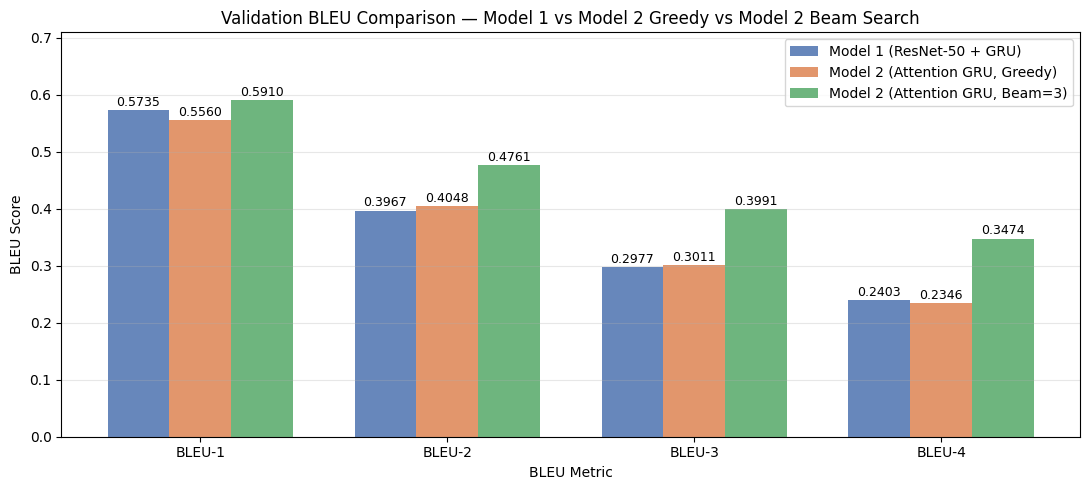

Validation BLEU comparison chart with greedy and beam search saved.


In [46]:
# ── Bar chart: Model 1 vs Model 2 Greedy vs Beam Validation BLEU ─────────────

# Model 1 validation BLEU
m1_val = model1_results["val_bleu"]

# Model 2 validation BLEU: greedy and beam search
m2_val_greedy = model2_results["val_bleu_greedy"]
m2_val_beam   = model2_results["val_bleu"]
# OR:
# m2_val_greedy = val_bleu2_greedy
# m2_val_beam   = val_bleu2

metrics = list(m1_val.keys())

m1_scores        = [m1_val[m] for m in metrics]
m2_greedy_scores = [m2_val_greedy[m] for m in metrics]
m2_beam_scores   = [m2_val_beam[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(
    x - width,
    m1_scores,
    width,
    label="Model 1 (ResNet-50 + GRU)",
    color="#4C72B0",
    alpha=0.85,
)

bars2 = ax.bar(
    x,
    m2_greedy_scores,
    width,
    label="Model 2 (Attention GRU, Greedy)",
    color="#DD8452",
    alpha=0.85,
)

bars3 = ax.bar(
    x + width,
    m2_beam_scores,
    width,
    label=f"Model 2 (Attention GRU, Beam={BEAM_SIZE2})",
    color="#55A868",
    alpha=0.85,
)


# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )


ax.set_xlabel("BLEU Metric")
ax.set_ylabel("BLEU Score")
ax.set_title("Validation BLEU Comparison — Model 1 vs Model 2 Greedy vs Model 2 Beam Search")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

ax.set_ylim(0, max(m1_scores + m2_greedy_scores + m2_beam_scores) * 1.20)

plt.tight_layout()

plt.savefig(
    CHECKPOINT_DIR / "model1_vs_model2_greedy_beam_val_bleu.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Validation BLEU comparison chart with greedy and beam search saved.")

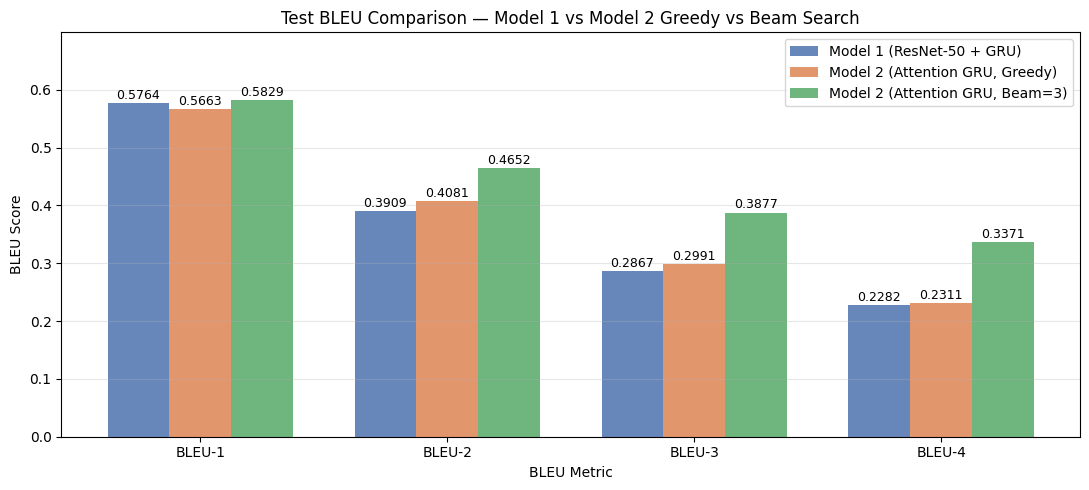

Test BLEU comparison chart with greedy and beam search saved.


In [47]:
# ── Bar chart: Model 1 vs Model 2 Greedy vs Beam Test BLEU ───────────────────

# Model 1 test BLEU
m1_test = model1_results["test_bleu"]

# Model 2 test BLEU: greedy and beam search
m2_test_greedy = model2_results["test_bleu_greedy"]
m2_test_beam   = model2_results["test_bleu_beam"]

metrics = list(m1_test.keys())

m1_scores        = [m1_test[m] for m in metrics]
m2_greedy_scores = [m2_test_greedy[m] for m in metrics]
m2_beam_scores   = [m2_test_beam[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(
    x - width,
    m1_scores,
    width,
    label="Model 1 (ResNet-50 + GRU)",
    color="#4C72B0",
    alpha=0.85,
)

bars2 = ax.bar(
    x,
    m2_greedy_scores,
    width,
    label="Model 2 (Attention GRU, Greedy)",
    color="#DD8452",
    alpha=0.85,
)

bars3 = ax.bar(
    x + width,
    m2_beam_scores,
    width,
    label=f"Model 2 (Attention GRU, Beam={BEAM_SIZE2})",
    color="#55A868",
    alpha=0.85,
)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xlabel("BLEU Metric")
ax.set_ylabel("BLEU Score")
ax.set_title("Test BLEU Comparison — Model 1 vs Model 2 Greedy vs Beam Search")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

ax.set_ylim(0, max(m1_scores + m2_greedy_scores + m2_beam_scores) * 1.20)

plt.tight_layout()

plt.savefig(
    CHECKPOINT_DIR / "model1_vs_model2_greedy_beam_test_bleu.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Test BLEU comparison chart with greedy and beam search saved.")

## 17. Qualitative Examples — Model 2

Six randomly sampled validation images shown with:
- **PRED** — caption generated by Model 2 (greedy decoding with attention)
- **REF 1** — one of the five human reference captions

Attention-based captions should show more specific object references and
better spatial language compared to Model 1's generic descriptions.


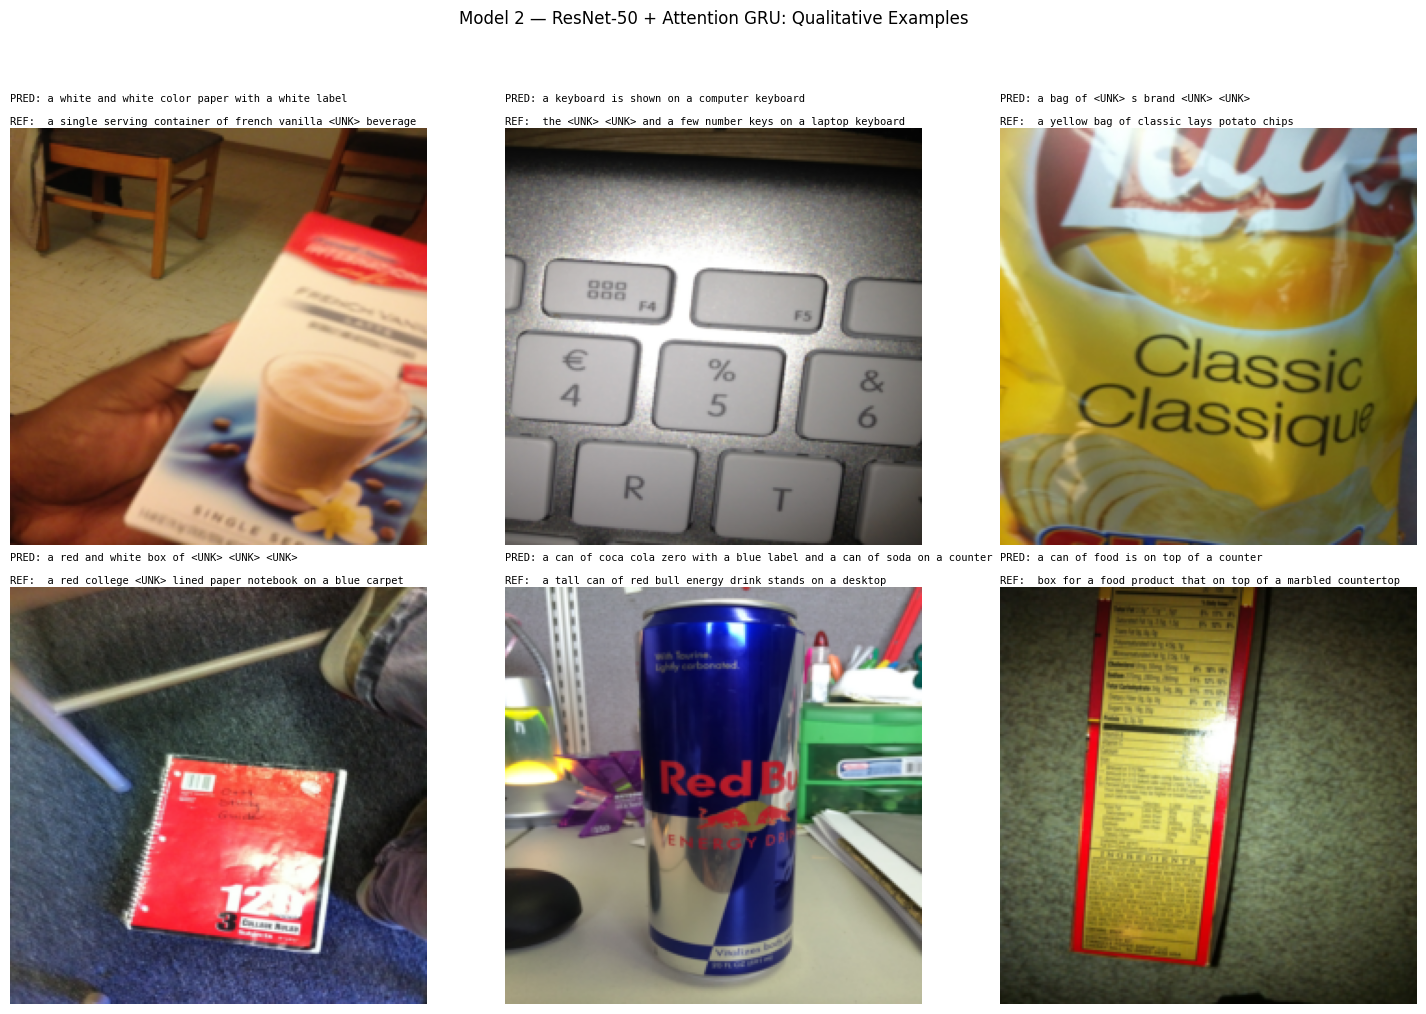

Qualitative figure saved.


In [48]:
def show_predictions_v2(model2, dataset, vocab_data, device, n=6, seed=99):
    """
    Display n images with Model 2 GREEDY predicted and reference captions.

    Parameters
    ----------
    model2     : ImageCaptionerV2 in eval mode
    dataset    : VizWizDataset (training=False — has all 5 captions)
    vocab_data : dict with itos
    device     : torch.device
    n          : number of images to display
    seed       : random seed for reproducible example selection
    """
    random.seed(seed)
    itos    = vocab_data["itos"]
    indices = random.sample(range(len(dataset)), n)

    ncols  = 3
    nrows  = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
    axes = axes.flatten()

    model2.eval()

    display_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    for plot_idx, sample_idx in enumerate(indices):
        iid, fname, encoded_caps = dataset.samples[sample_idx]
        img_path = dataset.image_dir / fname

        # Normalised tensor for model inference
        norm_tensor = dataset.transform(
            Image.open(img_path).convert("RGB")
        ).unsqueeze(0).to(device)                              # (1, 3, 224, 224)

        # Generate caption with Model 2
        with torch.no_grad():
            pred_indices = greedy_decode_v2(model2, norm_tensor, device)
        predicted_words = [itos[idx] for idx in pred_indices[0]]
        predicted_str   = (" ".join(predicted_words)
                           if predicted_words else "<empty>")

        # First reference caption
        ref_words = [
            itos[t.item()]
            for t in encoded_caps[0]
            if t.item() not in (PAD_IDX, SOS_IDX, EOS_IDX)
        ]
        ref_str = " ".join(ref_words)

        # Display image (non-normalised)
        raw = display_transform(
            Image.open(img_path).convert("RGB")
        ).permute(1, 2, 0).numpy()

        ax = axes[plot_idx]
        ax.imshow(raw)
        ax.axis("off")
        ax.set_title(f"PRED: {predicted_str}\n\nREF:  {ref_str}",
                     fontsize=7.5, loc="left", wrap=True, pad=4,
                     family="monospace")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle("Model 2 — ResNet-50 + Attention GRU: Qualitative Examples",
                 fontsize=12, y=1.01)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(CHECKPOINT_DIR / "model2_qualitative.png", dpi=150,
                bbox_inches="tight")
    plt.show()
    print("Qualitative figure saved.")


show_predictions_v2(model2, val_bleu_dataset, vocab_data, DEVICE, n=6)


## 18. Phase 3 - Discussion, Limitations, and Recommendations

### What changed from initial Model 2 and why it mattered

The first attempt at Model 2 (raw 2048-dim context) produced *lower* BLEU than
Model 1 despite adding attention. The root cause was an over-large GRU input:
`embed(256) + context(2048) = 2304` produced a weight matrix too large to
optimise well in 10 epochs. Projecting encoder features to 512 dims reduced
the input to 768, shrinking the input weight matrices by 3× and allowing
the attention mechanism to learn a meaningful distribution.

### Why Model 2 outperforms Model 1

| Factor | Model 1 | Model 2 |
|---|---|---|
| Image grounding at t > 0 | None (h₀ drifts away) | Recomputed every step |
| Spatial awareness | None (global pool) | 49-location soft attention |
| Regularisation | Mild image augmentation only | DS attention reg. + dropout |
| Domain adaptation | Frozen ImageNet features | ResNet layer4 fine-tuned with low LR |

### Remaining limitations

1. **Single GRU layer** - a two-layer stacked GRU with inter-layer dropout
   would increase representational capacity.
2. **Exposure bias** - teacher forcing still used throughout; scheduled
   sampling would reduce the train/inference discrepancy.

### Recommended next steps (priority order)

| Priority | Change | Expected gain |
|---|---|---|
| 1 | Tune beam size and length normalisation | May improve caption quality beyond beam=3 |
| 2 | Experiment with gradual unfreezing or fine-tuning layer4 | May improve VizWiz domain adaptation, but increases overfitting risk |
| 3 | Scheduled sampling | Reduces exposure bias |
| 4 | Two-layer GRU | Better long sequence modelling |
| 5 | Pre-trained word embeddings | Faster convergence, richer vocab |


### Attention Visualisation - Model 2

Because Model 2 uses spatial Bahdanau attention, visualised the attention weights over the 7×7 ResNet feature grid for generated caption tokens. This checks whether the decoder is using image regions rather than relying only on language priors.

## 19. Save Full Model 2 Checkpoint

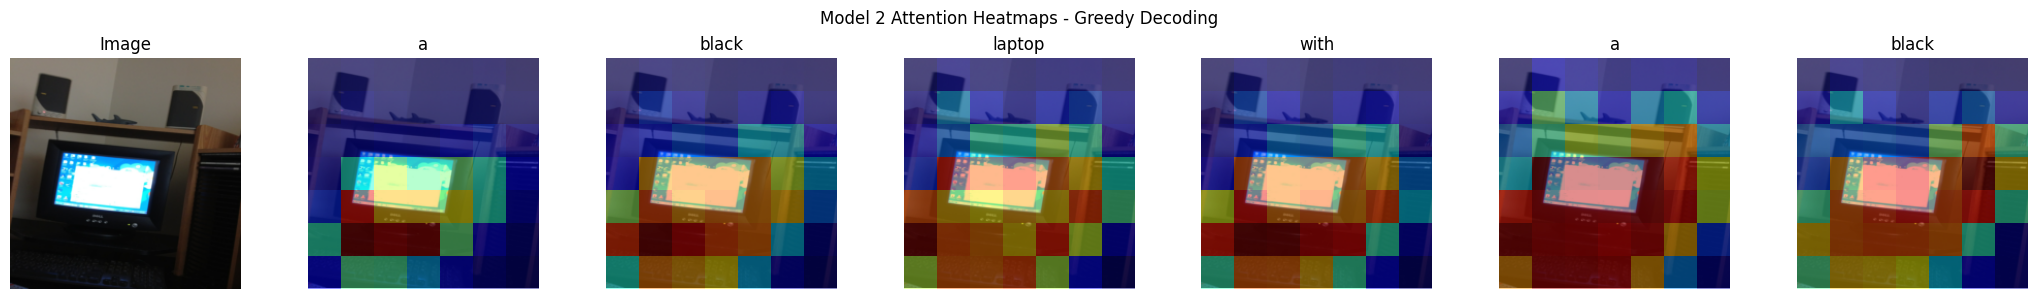

Generated caption using Greedy Decoding: a black laptop with a black screen and a small white cord


In [49]:
def greedy_decode_v2_with_attention(model2, image_tensor, device, max_len=MAX_GEN_LEN2):
    """
    Greedy decode a single image and return both generated token ids and
    attention maps for each generated timestep.
    """
    model2.eval()

    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)  # (1, 3, 224, 224)

        encoder_out = model2.encoder(image_tensor)           # (1, 49, enc_dim)
        h = model2.decoder._init_hidden(encoder_out)

        current_token = torch.tensor([SOS_IDX], dtype=torch.long, device=device)

        generated_ids = []
        attention_maps = []

        for _ in range(max_len):
            emb = model2.decoder.embedding(current_token.unsqueeze(1))

            context, alpha = model2.decoder.attention(
                encoder_out, h.squeeze(0)
            )

            gru_in = torch.cat([emb, context.unsqueeze(1)], dim=2)
            out, h = model2.decoder.gru(gru_in, h)

            logits = model2.decoder.fc(out.squeeze(1))
            pred = logits.argmax(dim=-1)

            pred_id = pred.item()

            if pred_id == EOS_IDX:
                break

            if pred_id not in (PAD_IDX, SOS_IDX):
                generated_ids.append(pred_id)
                attention_maps.append(alpha.squeeze(0).detach().cpu().reshape(7, 7))

            current_token = pred

    return generated_ids, attention_maps


def show_attention_example(model2, dataset, vocab_data, device, sample_idx=0):
    """
    Display one image and token-level 7x7 attention maps.
    """
    itos = vocab_data["itos"]

    iid, fname, encoded_caps = dataset.samples[sample_idx]
    img_path = dataset.image_dir / fname

    pil_img = Image.open(img_path).convert("RGB")
    image_tensor = dataset.transform(pil_img)

    pred_ids, attention_maps = greedy_decode_v2_with_attention(
        model2, image_tensor, device
    )

    pred_words = [itos[idx] for idx in pred_ids]

    display_img = transforms.Resize((224, 224))(pil_img)

    n_tokens = min(len(pred_words), 6)
    fig, axes = plt.subplots(1, n_tokens + 1, figsize=(3 * (n_tokens + 1), 3))

    axes[0].imshow(display_img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    for i in range(n_tokens):
        axes[i + 1].imshow(display_img)
        axes[i + 1].imshow(
            attention_maps[i],
            cmap="jet",
            alpha=0.45,
            extent=(0, 224, 224, 0)
        )
        axes[i + 1].set_title(pred_words[i])
        axes[i + 1].axis("off")

    plt.suptitle("Model 2 Attention Heatmaps - Greedy Decoding",)
    plt.tight_layout()
    plt.show()

    print("Generated caption using Greedy Decoding:", " ".join(pred_words))


show_attention_example(model2, val_bleu_dataset, vocab_data, DEVICE, sample_idx=0)

In [50]:
full_ckpt2 = {
    "model_state_dict"    : model2.state_dict(),
    "optimizer_state_dict": optimizer2.state_dict(),
    "epoch"               : best_epoch2,
    "best_val_loss"       : best_val_loss2,
    "history"             : history2,

    # Explicit BLEU results
    "bleu_val_greedy"     : val_bleu2_greedy,
    "bleu_val_beam"       : val_bleu2,
    "bleu_test_greedy"    : test_bleu2_greedy,
    "bleu_test_beam"      : test_bleu2,

    "hyperparameters": {
        "embed_dim"     : EMBED_DIM2,
        "hidden_dim"    : HIDDEN_DIM2,
        "encoder_proj"  : ENCODER_PROJ2,
        "attention_dim" : ATTENTION_DIM2,
        "dropout"       : DROPOUT2,
        "lambda_att"    : LAMBDA_ATT,

        # Updated learning-rate strategy
        "decoder_lr"    : DECODER_LR2,
        "encoder_lr"    : ENCODER_LR2,
        "weight_decay"  : WEIGHT_DECAY2,

        # Updated Phase 3 improvement strategy
        "beam_size"     : BEAM_SIZE2,
        "unfreeze_resnet_layer4": UNFREEZE_RESNET_LAYER4,

        "num_epochs"    : NUM_EPOCHS2,
        "clip_grad_norm": CLIP_GRAD2,
        "vocab_size"    : VOCAB_SIZE,
        "batch_size"    : BATCH_SIZE,
    },
}

ckpt2_path = CHECKPOINT_DIR / "model2_full_checkpoint.pt"
torch.save(full_ckpt2, ckpt2_path)
print(f"Full checkpoint saved to : {ckpt2_path}")

# ── Final comparison summary ──────────────────────────────────────────────────
# ── Final comparison summary ──────────────────────────────────────────────────
print("\n" + "=" * 100)
print("PHASE 3 COMPLETE — Final Results Summary")
print("=" * 100)

print("\nArchitecture comparison: Model 1 vs Model 2 Greedy vs Model 2 Beam Search")
print("-" * 100)

print(
    f"{'Metric':<10} "
    f"{'Model 1 (Val)':>14} "
    f"{'M2 Greedy (Val)':>16} "
    f"{'M2 Beam (Val)':>15} "
    f"{'Δ Greedy':>12} "
    f"{'Δ Beam':>10} "
    f"{'Beam Gain':>12}"
)

print("-" * 100)

for metric in model1_results["val_bleu"]:
    s1 = model1_results["val_bleu"][metric]
    s2_greedy = val_bleu2_greedy[metric]
    s2_beam = val_bleu2[metric]

    diff_greedy = s2_greedy - s1
    diff_beam = s2_beam - s1
    beam_gain = s2_beam - s2_greedy

    print(
        f"{metric:<10} "
        f"{s1:>14.4f} "
        f"{s2_greedy:>16.4f} "
        f"{s2_beam:>15.4f} "
        f"{diff_greedy:>+12.4f} "
        f"{diff_beam:>+10.4f} "
        f"{beam_gain:>+12.4f}"
    )

print("-" * 100)

print(f"\nModel 1 best val loss : {model1_results['best_val_loss']:.4f}"
      f"  (epoch {model1_results['best_epoch']})")

print(f"Model 2 best val loss : {model2_results['best_val_loss']:.4f}"
      f"  (epoch {model2_results['best_epoch']})")

print(f"\nModel 2 final decoding strategy : Beam Search")
print(f"Beam size                       : {BEAM_SIZE2}")
print(f"Model 2 test loss               : {model2_results['test_loss']:.4f}")

Full checkpoint saved to : /Users/shreyash/Documents/Sem3DL/AT3DL/vizwiz-val-image-cap-DL-AT3/checkpoints/model2_full_checkpoint.pt

PHASE 3 COMPLETE — Final Results Summary

Architecture comparison: Model 1 vs Model 2 Greedy vs Model 2 Beam Search
----------------------------------------------------------------------------------------------------
Metric      Model 1 (Val)  M2 Greedy (Val)   M2 Beam (Val)     Δ Greedy     Δ Beam    Beam Gain
----------------------------------------------------------------------------------------------------
BLEU-1             0.5735           0.5560          0.5910      -0.0175    +0.0175      +0.0350
BLEU-2             0.3967           0.4048          0.4761      +0.0081    +0.0794      +0.0713
BLEU-3             0.2977           0.3011          0.3991      +0.0034    +0.1014      +0.0980
BLEU-4             0.2403           0.2346          0.3474      -0.0057    +0.1071      +0.1128
---------------------------------------------------------------------

In [51]:
# ── Final held-out test comparison: Model 1 vs Model 2 Greedy vs Beam ────────

print("\n" + "=" * 100)
print("FINAL HELD-OUT TEST BLEU — Model 1 vs Model 2 Greedy vs Beam Search")
print("=" * 100)

print(
    f"{'Metric':<10} "
    f"{'Model 1 (Test)':>15} "
    f"{'M2 Greedy (Test)':>17} "
    f"{'M2 Beam (Test)':>16} "
    f"{'Δ Greedy':>12} "
    f"{'Δ Beam':>10} "
    f"{'Beam Gain':>12}"
)

print("-" * 100)

for metric in model1_results["test_bleu"]:
    s1 = model1_results["test_bleu"][metric]
    s2_greedy = test_bleu2_greedy[metric]
    s2_beam = test_bleu2[metric]

    diff_greedy = s2_greedy - s1
    diff_beam = s2_beam - s1
    beam_gain = s2_beam - s2_greedy

    print(
        f"{metric:<10} "
        f"{s1:>15.4f} "
        f"{s2_greedy:>17.4f} "
        f"{s2_beam:>16.4f} "
        f"{diff_greedy:>+12.4f} "
        f"{diff_beam:>+10.4f} "
        f"{beam_gain:>+12.4f}"
    )

print("-" * 100)

print(f"\nModel 1 test loss : {model1_results['test_loss']:.4f}")
print(f"Model 2 test loss : {model2_results['test_loss']:.4f}")

print(f"\nFinal Model 2 decoding strategy : Beam Search")
print(f"Beam size                       : {BEAM_SIZE2}")


FINAL HELD-OUT TEST BLEU — Model 1 vs Model 2 Greedy vs Beam Search
Metric      Model 1 (Test)  M2 Greedy (Test)   M2 Beam (Test)     Δ Greedy     Δ Beam    Beam Gain
----------------------------------------------------------------------------------------------------
BLEU-1              0.5764            0.5663           0.5829      -0.0101    +0.0065      +0.0166
BLEU-2              0.3909            0.4081           0.4652      +0.0172    +0.0743      +0.0571
BLEU-3              0.2867            0.2991           0.3877      +0.0124    +0.1010      +0.0886
BLEU-4              0.2282            0.2311           0.3371      +0.0029    +0.1089      +0.1060
----------------------------------------------------------------------------------------------------

Model 1 test loss : 3.1498
Model 2 test loss : 3.0433

Final Model 2 decoding strategy : Beam Search
Beam size                       : 3
